In [2]:
# 第一步：挂载drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Load the CSV
csv_path = '/content/drive/MyDrive/segmented_images/segmentation_summary.csv'
df = pd.read_csv(csv_path)

print(df.shape)
print(df.columns.tolist())
print("\nFirst row:")
print(df.iloc[0])

# Check if mask_path is accessible
import os
first_mask = df['mask_path'].iloc[0]
print(f"\nMask path in CSV: {first_mask}")
print(f"File exists: {os.path.exists(first_mask)}")

(1530, 7)
['idx', 'patient_id', 'view', 'birads', 'img_path', 'mask_path', 'dice']

First row:
idx                                                           0
patient_id                                              P_00001
view                                                         CC
birads                                                        4
img_path      /content/drive/MyDrive/Projects in Biomedical ...
mask_path     /content/drive/MyDrive/Projects in Biomedical ...
dice                                                     0.6327
Name: 0, dtype: object

Mask path in CSV: /content/drive/MyDrive/Projects in Biomedical AI Group Proj/Data/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
File exists: False


In [3]:
import os

# Check if seg_XXXX.png files match the idx column
seg_folder = '/content/drive/MyDrive/segmented_images/'

# Test first 3 rows
for i in range(3):
    row = df.iloc[i]
    # Construct mask path from idx
    mask_filename = f"seg_{int(row['idx']):04d}.png"
    mask_path = os.path.join(seg_folder, mask_filename)
    print(f"idx={int(row['idx'])} | {row['patient_id']} | {row['view']} | exists: {os.path.exists(mask_path)}")

# Also check img_path - can we access the original images?
print("\nChecking original image access:")
print(f"img_path exists: {os.path.exists(df['img_path'].iloc[0])}")
print(f"\nOriginal img_path: {df['img_path'].iloc[0]}")

idx=0 | P_00001 | CC | exists: True
idx=1 | P_00004 | MLO | exists: True
idx=2 | P_00021 | CC | exists: True

Checking original image access:
img_path exists: False

Original img_path: /content/drive/MyDrive/Projects in Biomedical AI Group Proj/Data/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg


In [4]:
import os

# Get the UID from Haiya's path
sample_path = df['img_path'].iloc[0]
parts = sample_path.split('/')
uid_haiya = parts[-2]
filename = parts[-1]

print(f"Haiya's UID: {uid_haiya}")
print(f"Filename: {filename}")

# List all UIDs in your dataset and check if it exists
jpeg_base = '/content/drive/MyDrive/cbis_ddsm_dataset/jpeg/'
all_uids = os.listdir(jpeg_base)
print(f"\nTotal UID folders in your dataset: {len(all_uids)}")

# Exact match check
print(f"Exact match: {uid_haiya in all_uids}")

# Check if the UID is a substring of any folder
matches = [u for u in all_uids if uid_haiya in u or u in uid_haiya]
print(f"Partial matches: {matches}")

# Try opening the folder directly
direct_path = os.path.join(jpeg_base, uid_haiya)
print(f"\nDirect path exists: {os.path.exists(direct_path)}")

# List files inside if it exists, else show a sample UID folder
if not os.path.exists(direct_path):
    sample_uid = all_uids[0]
    sample_files = os.listdir(os.path.join(jpeg_base, sample_uid))
    print(f"\nSample UID folder '{sample_uid}' contains: {sample_files}")

Haiya's UID: 1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
Filename: 1-211.jpg

Total UID folders in your dataset: 6740
Exact match: True
Partial matches: ['1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515']

Direct path exists: True


Total records: 1530

Path verification (first 3 rows):
  P_00001 | CC
    img  exists: False
    mask exists: True
  P_00004 | MLO
    img  exists: False
    mask exists: True
  P_00021 | CC
    img  exists: False
    mask exists: True

Dice >= 0.5: 1329 records kept
Dice <  0.5: 201  records dropped

Successfully generated bbox: 1329
Failed: 0

After merging: 1180 unique patient+view records

CC+MLO paired (usable for alignment): 233 patients
CC only:  325 patients
MLO only: 389 patients

JSON saved to: /content/drive/MyDrive/segmented_images/bbox_results.json


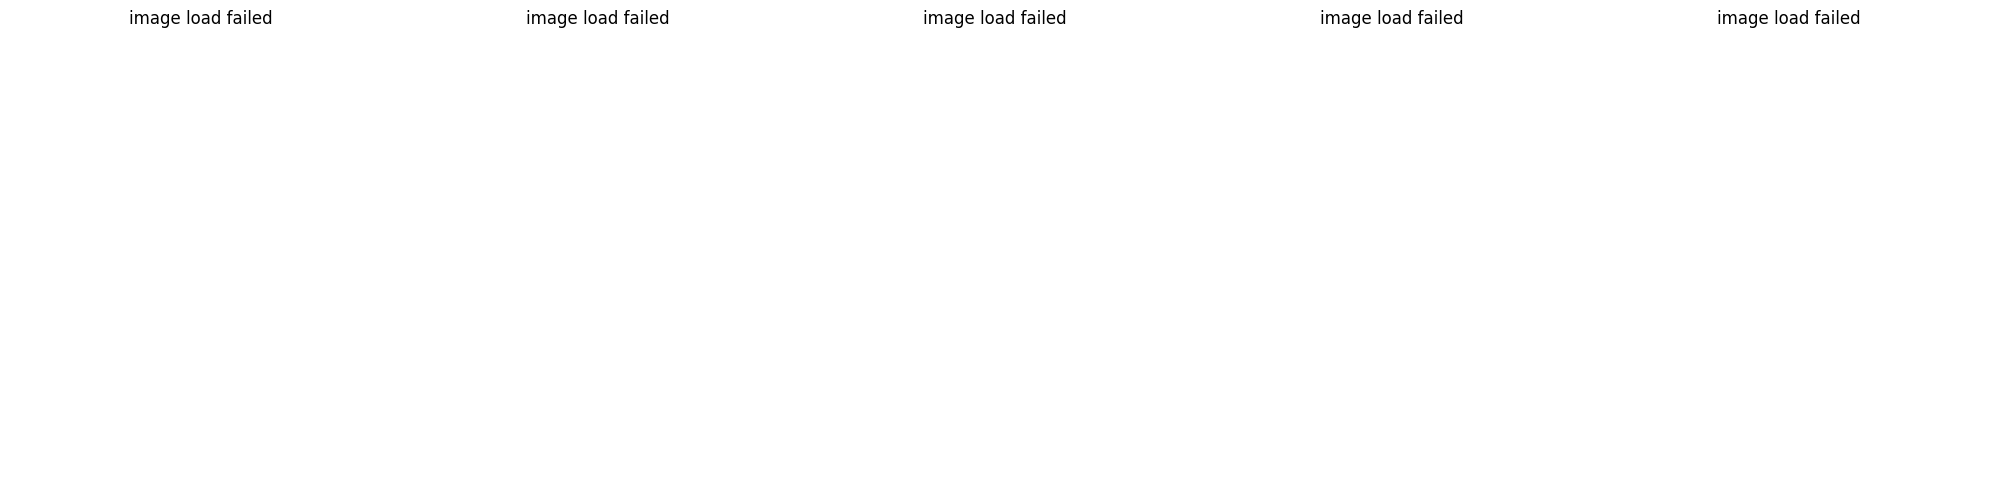

Visualization saved


In [5]:
import pandas as pd
import numpy as np
import cv2
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import random

# ============================================================
# CONFIG - change these paths if needed
# ============================================================
CSV_PATH      = '/content/drive/MyDrive/segmented_images/segmentation_summary.csv'
SEG_FOLDER    = '/content/drive/MyDrive/segmented_images/'
JPEG_BASE     = '/content/drive/MyDrive/cbis_ddsm_dataset/jpeg/'
OUTPUT_JSON   = '/content/drive/MyDrive/segmented_images/bbox_results.json'
OUTPUT_VIZ    = '/content/drive/MyDrive/segmented_images/bbox_visualization.png'
DICE_THRESHOLD = 0.5

# ============================================================
# 1. Load CSV and fix paths
# ============================================================
df = pd.read_csv(CSV_PATH)
print(f"Total records: {len(df)}")

def fix_img_path(original_path):
    """Reconstruct img_path using local cbis_ddsm_dataset"""
    parts = original_path.split('/')
    uid      = parts[-2]
    filename = parts[-1]
    return os.path.join(JPEG_BASE, uid, filename)

def get_mask_path(idx):
    """Construct mask path from idx -> seg_XXXX.png"""
    return os.path.join(SEG_FOLDER, f"seg_{int(idx):04d}.png")

# Apply path fixes
df['img_path_local']  = df['img_path'].apply(fix_img_path)
df['mask_path_local'] = df['idx'].apply(get_mask_path)

# Verify on first 3 rows
print("\nPath verification (first 3 rows):")
for i in range(3):
    row = df.iloc[i]
    print(f"  {row['patient_id']} | {row['view']}")
    print(f"    img  exists: {os.path.exists(row['img_path_local'])}")
    print(f"    mask exists: {os.path.exists(row['mask_path_local'])}")

# ============================================================
# 2. Filter by dice threshold
# ============================================================
df_filtered = df[df['dice'] >= DICE_THRESHOLD].copy()
df_dropped  = df[df['dice'] <  DICE_THRESHOLD].copy()
print(f"\nDice >= {DICE_THRESHOLD}: {len(df_filtered)} records kept")
print(f"Dice <  {DICE_THRESHOLD}: {len(df_dropped)}  records dropped")

# ============================================================
# 3. mask -> bounding box
# ============================================================
def mask_to_bbox(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None, None, None

    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None, None

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 10:
        return None, None, None

    x, y, w, h = cv2.boundingRect(largest)
    img_h, img_w = mask.shape
    return [x, y, w, h], [img_w, img_h], area

# ============================================================
# 4. Process all rows
# ============================================================
records = []
failed  = []

for _, row in df_filtered.iterrows():
    bbox, img_size, area = mask_to_bbox(row['mask_path_local'])

    if bbox is None:
        failed.append({
            'patient_id': row['patient_id'],
            'view':       row['view'],
            'reason':     'mask read failed or no contour'
        })
        continue

    records.append({
        'patient_id':  row['patient_id'],
        'view':        row['view'],
        'birads':      int(row['birads']),
        'img_path':    row['img_path_local'],
        'mask_path':   row['mask_path_local'],
        'bbox':        bbox,          # [x, y, w, h]
        'img_size':    img_size,      # [width, height]
        'lesion_area': int(area),
        'dice':        round(float(row['dice']), 4)
    })

print(f"\nSuccessfully generated bbox: {len(records)}")
print(f"Failed: {len(failed)}")

# ============================================================
# 5. Merge multiple lesions for same patient+view
# ============================================================
def merge_bboxes(bbox_list):
    x_min = min(b[0]        for b in bbox_list)
    y_min = min(b[1]        for b in bbox_list)
    x_max = max(b[0] + b[2] for b in bbox_list)
    y_max = max(b[1] + b[3] for b in bbox_list)
    return [x_min, y_min, x_max - x_min, y_max - y_min]

grouped = defaultdict(list)
for r in records:
    grouped[(r['patient_id'], r['view'])].append(r)

merged_records = []
for (patient_id, view), group in grouped.items():
    if len(group) == 1:
        merged_records.append(group[0])
    else:
        best = max(group, key=lambda x: x['dice'])
        merged_records.append({
            'patient_id':  patient_id,
            'view':        view,
            'birads':      best['birads'],
            'img_path':    best['img_path'],
            'mask_path':   best['mask_path'],
            'bbox':        merge_bboxes([g['bbox'] for g in group]),
            'img_size':    best['img_size'],
            'lesion_area': sum(g['lesion_area'] for g in group),
            'dice':        round(sum(g['dice'] for g in group) / len(group), 4),
            'num_lesions': len(group)
        })

print(f"\nAfter merging: {len(merged_records)} unique patient+view records")

# ============================================================
# 6. CC/MLO pairing stats
# ============================================================
patient_views = defaultdict(set)
for r in merged_records:
    patient_views[r['patient_id']].add(r['view'])

paired   = [p for p, v in patient_views.items() if {'CC','MLO'} <= v]
cc_only  = [p for p, v in patient_views.items() if v == {'CC'}]
mlo_only = [p for p, v in patient_views.items() if v == {'MLO'}]

print(f"\nCC+MLO paired (usable for alignment): {len(paired)} patients")
print(f"CC only:  {len(cc_only)} patients")
print(f"MLO only: {len(mlo_only)} patients")

# ============================================================
# 7. Save JSON for Tushar
# ============================================================
output = {
    'metadata': {
        'dice_threshold':  DICE_THRESHOLD,
        'total_records':   len(merged_records),
        'paired_patients': len(paired),
        'cc_only':         len(cc_only),
        'mlo_only':        len(mlo_only)
    },
    'detections': merged_records
}

with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)

print(f"\nJSON saved to: {OUTPUT_JSON}")

# ============================================================
# 8. Visualization - check 5 random samples
# ============================================================
samples = random.sample(merged_records, min(5, len(merged_records)))
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, r in zip(axes, samples):
    img = cv2.imread(r['img_path'], cv2.IMREAD_GRAYSCALE)
    if img is None:
        ax.set_title('image load failed')
        ax.axis('off')
        continue

    x, y, w, h = r['bbox']
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)

    ax.imshow(img_rgb, cmap='gray')
    ax.set_title(f"{r['patient_id']}\n{r['view']} | BI-RADS {r['birads']}\nDice={r['dice']}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_VIZ, dpi=150)
plt.show()
print("Visualization saved")

Shape: (476, 1857, 3)
Full image: 1857x476
Each panel width: 464


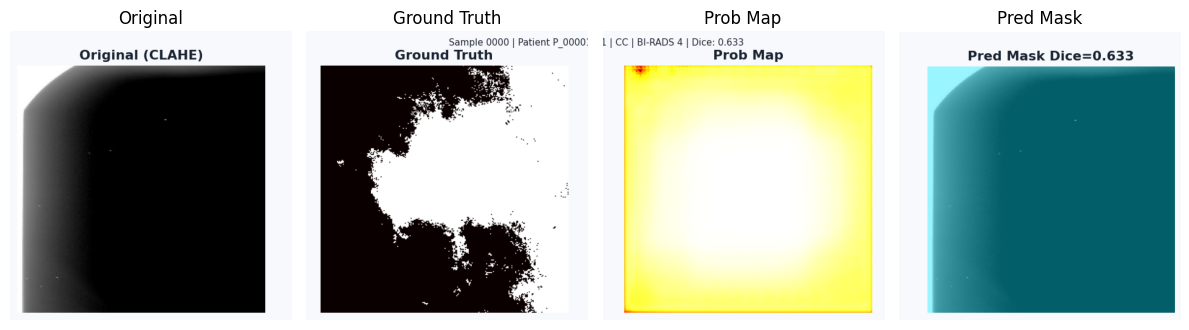

In [9]:
import cv2
import matplotlib.pyplot as plt

# Load one seg image and check its dimensions
test = cv2.imread('/content/drive/MyDrive/segmented_images/seg_0000.png')
print(f"Shape: {test.shape}")  # height, width, channels

# Each panel should be roughly width/4
h, w = test.shape[:2]
panel_w = w // 4
print(f"Full image: {w}x{h}")
print(f"Each panel width: {panel_w}")

# Crop out the 4 panels
panel1 = test[:, 0:panel_w]           # Original (CLAHE)
panel2 = test[:, panel_w:panel_w*2]   # Ground Truth mask
panel3 = test[:, panel_w*2:panel_w*3] # Prob Map
panel4 = test[:, panel_w*3:]          # Pred Mask

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
titles = ['Original', 'Ground Truth', 'Prob Map', 'Pred Mask']
for ax, panel, title in zip(axes, [panel1, panel2, panel3, panel4], titles):
    ax.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# Check the official CBIS-DDSM annotations
mass_train = pd.read_csv('/content/drive/MyDrive/cbis_ddsm_dataset/csv/mass_case_description_train_set.csv')
mass_test  = pd.read_csv('/content/drive/MyDrive/cbis_ddsm_dataset/csv/mass_case_description_test_set.csv')

print(mass_train.columns.tolist())
print(mass_train.head(3))

['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   
1    P_00001               3                 LEFT        MLO               1   
2    P_00004               3                 LEFT         CC               1   

  abnormality type                          mass shape mass margins  \
0             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
1             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
2             mass            ARCHITECTURAL_DISTORTION  ILL_DEFINED   

   assessment  pathology  subtlety  \
0           4  MALIGNANT         4   
1           4  MALIGNANT         4   
2           4     BENIGN         3

In [12]:
# Print raw path strings to understand the format
print("Raw image file path:")
print(repr(mass_train['image file path'].iloc[0]))
print()
print("Raw ROI mask file path:")
print(repr(mass_train['ROI mask file path'].iloc[0]))
print()

# Check all parts when split by /
path = mass_train['image file path'].iloc[0]
parts = path.strip().split('/')
for i, p in enumerate(parts):
    print(f"  parts[{i}]: {p}")

Raw image file path:
'Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm'

Raw ROI mask file path:
'Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000001.dcm\n'

  parts[0]: Mass-Training_P_00001_LEFT_CC
  parts[1]: 1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994
  parts[2]: 1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
  parts[3]: 000000.dcm


In [14]:
# Check what files are actually inside these UID folders
uid_img  = '1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515'
uid_mask = '1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650'

img_folder  = os.path.join(JPEG_BASE, uid_img)
mask_folder = os.path.join(JPEG_BASE, uid_mask)

print(f"img folder exists:  {os.path.exists(img_folder)}")
print(f"mask folder exists: {os.path.exists(mask_folder)}")

if os.path.exists(img_folder):
    print(f"img files:  {os.listdir(img_folder)}")
if os.path.exists(mask_folder):
    print(f"mask files: {os.listdir(mask_folder)}")

img folder exists:  True
mask folder exists: True
img files:  []
mask files: ['2-249.jpg', '1-250.jpg']


In [15]:
import os

def parse_to_local(path_str):
    if pd.isna(path_str):
        return None
    parts = path_str.strip().split('/')
    if len(parts) < 3:
        return None
    uid2 = parts[2]
    folder_path = os.path.join(JPEG_BASE, uid2)
    if not os.path.exists(folder_path):
        return None
    # Get actual filename from folder (don't assume filename)
    files = os.listdir(folder_path)
    if not files:
        return None
    # Pick the jpg file
    jpgs = [f for f in files if f.endswith('.jpg')]
    if not jpgs:
        return None
    return os.path.join(folder_path, jpgs[0])

# Test
print("Testing:")
for i in range(3):
    row = df_all.iloc[i]
    img_path  = parse_to_local(row['image file path'])
    mask_path = parse_to_local(row['ROI mask file path'])
    print(f"\n  {row['patient_id']} | {row['image view']}")
    print(f"    img  -> {img_path}")
    print(f"    mask -> {mask_path}")

Testing:

  P_00001 | CC
    img  -> None
    mask -> /content/drive/MyDrive/cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg

  P_00001 | MLO
    img  -> None
    mask -> /content/drive/MyDrive/cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/2-288.jpg

  P_00004 | CC
    img  -> None
    mask -> /content/drive/MyDrive/cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg


Total records:   1696
Masks found:     1688/1696
Images found:    172/1696

Successfully generated bbox: 1688
Failed:                      8
After merging: 1520 unique patient+view records

CC+MLO paired (usable for alignment): 628 patients
CC only:  81 patients
MLO only: 183 patients

JSON saved: /content/drive/MyDrive/segmented_images/bbox_results_final.json


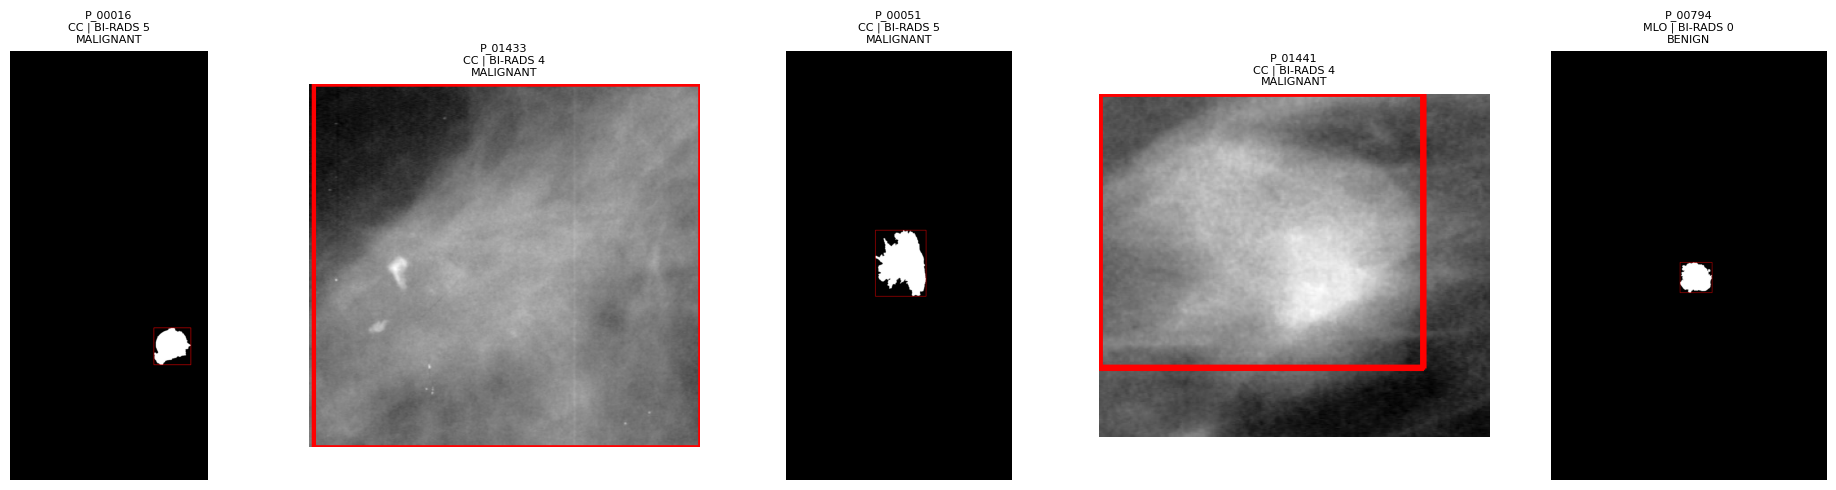

Done!


In [16]:
import pandas as pd
import cv2
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import random

# ============================================================
# CONFIG
# ============================================================
JPEG_BASE   = '/content/drive/MyDrive/cbis_ddsm_dataset/jpeg/'
OUTPUT_JSON = '/content/drive/MyDrive/segmented_images/bbox_results_final.json'

# ============================================================
# 1. Reload CSVs and apply fixed path parser
# ============================================================
mass_train = pd.read_csv('/content/drive/MyDrive/cbis_ddsm_dataset/csv/mass_case_description_train_set.csv')
mass_test  = pd.read_csv('/content/drive/MyDrive/cbis_ddsm_dataset/csv/mass_case_description_test_set.csv')
df_all = pd.concat([mass_train, mass_test], ignore_index=True)

def parse_to_local(path_str):
    if pd.isna(path_str):
        return None
    parts = path_str.strip().split('/')
    if len(parts) < 3:
        return None
    uid2 = parts[2]
    folder_path = os.path.join(JPEG_BASE, uid2)
    if not os.path.exists(folder_path):
        return None
    jpgs = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
    if not jpgs:
        return None
    return os.path.join(folder_path, jpgs[0])

df_all['mask_path_local'] = df_all['ROI mask file path'].apply(parse_to_local)
df_all['img_path_local']  = df_all['image file path'].apply(parse_to_local)

found_masks = df_all['mask_path_local'].notna().sum()
found_imgs  = df_all['img_path_local'].notna().sum()
print(f"Total records:   {len(df_all)}")
print(f"Masks found:     {found_masks}/{len(df_all)}")
print(f"Images found:    {found_imgs}/{len(df_all)}")

# ============================================================
# 2. mask -> bbox
# ============================================================
def mask_to_bbox(mask_path):
    if not mask_path:
        return None, None, None
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None, None, None
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None, None
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 10:
        return None, None, None
    x, y, w, h = cv2.boundingRect(largest)
    img_h, img_w = mask.shape
    return [x, y, w, h], [img_w, img_h], area

# ============================================================
# 3. Process all rows
# ============================================================
records = []
failed  = []

for _, row in df_all.iterrows():
    bbox, img_size, area = mask_to_bbox(row['mask_path_local'])
    if bbox is None:
        failed.append({
            'patient_id': row['patient_id'],
            'view':       row['image view'],
            'reason':     'mask not found or no contour'
        })
        continue

    records.append({
        'patient_id':  row['patient_id'],
        'view':        row['image view'],
        'birads':      int(row['assessment']),
        'pathology':   row['pathology'],
        'img_path':    row['img_path_local'],   # may be None
        'mask_path':   row['mask_path_local'],
        'bbox':        bbox,                     # [x, y, w, h] on full image
        'img_size':    img_size,
        'lesion_area': int(area),
    })

print(f"\nSuccessfully generated bbox: {len(records)}")
print(f"Failed:                      {len(failed)}")

# ============================================================
# 4. Merge multiple lesions per patient+view
# ============================================================
def merge_bboxes(bbox_list):
    x_min = min(b[0]        for b in bbox_list)
    y_min = min(b[1]        for b in bbox_list)
    x_max = max(b[0] + b[2] for b in bbox_list)
    y_max = max(b[1] + b[3] for b in bbox_list)
    return [x_min, y_min, x_max - x_min, y_max - y_min]

grouped = defaultdict(list)
for r in records:
    grouped[(r['patient_id'], r['view'])].append(r)

merged_records = []
for (patient_id, view), group in grouped.items():
    if len(group) == 1:
        merged_records.append(group[0])
    else:
        best = max(group, key=lambda x: x['lesion_area'])
        merged_records.append({
            'patient_id':  patient_id,
            'view':        view,
            'birads':      best['birads'],
            'pathology':   best['pathology'],
            'img_path':    best['img_path'],
            'mask_path':   best['mask_path'],
            'bbox':        merge_bboxes([g['bbox'] for g in group]),
            'img_size':    best['img_size'],
            'lesion_area': sum(g['lesion_area'] for g in group),
            'num_lesions': len(group)
        })

print(f"After merging: {len(merged_records)} unique patient+view records")

# ============================================================
# 5. Pairing stats
# ============================================================
patient_views = defaultdict(set)
for r in merged_records:
    patient_views[r['patient_id']].add(r['view'])

paired   = [p for p, v in patient_views.items() if {'CC','MLO'} <= v]
cc_only  = [p for p, v in patient_views.items() if v == {'CC'}]
mlo_only = [p for p, v in patient_views.items() if v == {'MLO'}]

print(f"\nCC+MLO paired (usable for alignment): {len(paired)} patients")
print(f"CC only:  {len(cc_only)} patients")
print(f"MLO only: {len(mlo_only)} patients")

# ============================================================
# 6. Save JSON
# ============================================================
output = {
    'metadata': {
        'source':          'CBIS-DDSM official ROI masks',
        'total_records':   len(merged_records),
        'paired_patients': len(paired),
        'cc_only':         len(cc_only),
        'mlo_only':        len(mlo_only)
    },
    'detections': merged_records
}
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)
print(f"\nJSON saved: {OUTPUT_JSON}")

# ============================================================
# 7. Visualize with masks (since img not available)
# ============================================================
samples = random.sample(merged_records, min(5, len(merged_records)))
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, r in zip(axes, samples):
    mask = cv2.imread(r['mask_path'], cv2.IMREAD_GRAYSCALE)
    if mask is None:
        ax.set_title('load failed')
        ax.axis('off')
        continue
    x, y, w, h = r['bbox']
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(mask_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)
    ax.imshow(mask_rgb)
    ax.set_title(f"{r['patient_id']}\n{r['view']} | BI-RADS {r['birads']}\n{r['pathology']}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Done!")

In [1]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
print("Downloaded to:", path)

100%|██████████| 4.95G/4.95G [05:46<00:00, 15.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1


In [5]:
import os

JPEG_BASE = "/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/jpeg/"

# Check a few UID folders to see if they have files
uids = os.listdir(JPEG_BASE)
print(f"Total UID folders: {len(uids)}")

# Check first 5 folders
empty = 0
has_files = 0
for uid in uids[:20]:
    files = os.listdir(os.path.join(JPEG_BASE, uid))
    if files:
        has_files += 1
    else:
        empty += 1

print(f"First 20 folders - has files: {has_files}, empty: {empty}")

# Check the specific UID we know about
test_uid = '1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515'
test_path = os.path.join(JPEG_BASE, test_uid)
print(f"\nTest UID exists: {os.path.exists(test_path)}")
print(f"Test UID files: {os.listdir(test_path) if os.path.exists(test_path) else 'N/A'}")

Total UID folders: 6774
First 20 folders - has files: 20, empty: 0

Test UID exists: True
Test UID files: ['1-211.jpg']


In [3]:
import os
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
from collections import defaultdict
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
KAGGLE_BASE  = "/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1"
JPEG_BASE    = os.path.join(KAGGLE_BASE, "jpeg")
CSV_BASE     = os.path.join(KAGGLE_BASE, "csv")
YOLO_DIR     = "/content/yolo_dataset"
OUTPUT_JSON  = "/content/drive/MyDrive/segmented_images/bbox_results_yolo.json"
IMG_SIZE     = 640
EPOCHS       = 50
BATCH        = 16

# ============================================================
# 1. Load CSVs
# ============================================================
mass_train = pd.read_csv(os.path.join(CSV_BASE, "mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(CSV_BASE, "mass_case_description_test_set.csv"))
df_all = pd.concat([mass_train, mass_test], ignore_index=True)
print(f"Total records: {len(df_all)}")

# ============================================================
# 2. Path parser
# ============================================================
def get_local_path(path_str):
    if pd.isna(path_str):
        return None
    parts = path_str.strip().split('/')
    if len(parts) < 3:
        return None
    uid2 = parts[2]
    folder = os.path.join(JPEG_BASE, uid2)
    if not os.path.exists(folder):
        return None
    jpgs = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    if not jpgs:
        return None
    return os.path.join(folder, jpgs[0])

df_all['img_local']  = df_all['image file path'].apply(get_local_path)
df_all['mask_local'] = df_all['ROI mask file path'].apply(get_local_path)

# Keep only rows where both img and mask exist
df_valid = df_all[df_all['img_local'].notna() & df_all['mask_local'].notna()].copy()
print(f"Valid img+mask pairs: {len(df_valid)}")

# ============================================================
# 3. mask -> YOLO label
# ============================================================
def mask_to_yolo(mask_path, img_w, img_h):
    """
    Convert binary mask to YOLO format: cx cy w h (normalized 0-1)
    Returns None if no valid contour found
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    # Resize mask to match image dimensions if needed
    if mask.shape[1] != img_w or mask.shape[0] != img_h:
        mask = cv2.resize(mask, (img_w, img_h))

    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 10:
        return None

    x, y, w, h = cv2.boundingRect(largest)

    # Filter out bbox that covers too much of the image (bad mask)
    ratio = (w * h) / (img_w * img_h)
    if ratio > 0.5 or ratio < 0.001:
        return None

    # Convert to YOLO format (normalized cx, cy, w, h)
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    nw = w / img_w
    nh = h / img_h

    return [cx, cy, nw, nh], [x, y, w, h]

# ============================================================
# 4. Build YOLO dataset structure
# ============================================================
for split in ['train', 'val']:
    os.makedirs(f"{YOLO_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DIR}/labels/{split}", exist_ok=True)

# Merge multiple lesions per patient+view (take union bbox)
def merge_bboxes(bbox_list):
    x_min = min(b[0]        for b in bbox_list)
    y_min = min(b[1]        for b in bbox_list)
    x_max = max(b[0] + b[2] for b in bbox_list)
    y_max = max(b[1] + b[3] for b in bbox_list)
    return [x_min, y_min, x_max - x_min, y_max - y_min]

# Group by patient+view to avoid data leakage
grouped = defaultdict(list)
for _, row in df_valid.iterrows():
    key = (row['patient_id'], row['image view'])
    grouped[key].append(row)

# Split patients into train/val (80/20) at patient level
all_patients = list(set(row['patient_id'] for _, row in df_valid.iterrows()))
random.seed(42)
random.shuffle(all_patients)
split_idx    = int(len(all_patients) * 0.8)
train_patients = set(all_patients[:split_idx])
val_patients   = set(all_patients[split_idx:])

print(f"\nTrain patients: {len(train_patients)}")
print(f"Val patients:   {len(val_patients)}")

# Process each patient+view
records_for_json = []
skipped = 0
processed = 0

for (patient_id, view), rows in grouped.items():
    # Determine split
    split = 'train' if patient_id in train_patients else 'val'

    # Use first row's image (all rows same patient+view share same image)
    img_path = rows[0]['img_local']
    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img_h, img_w = img.shape[:2]

    # Get bbox from each lesion mask
    yolo_labels = []
    raw_bboxes  = []

    for row in rows:
        result = mask_to_yolo(row['mask_local'], img_w, img_h)
        if result is None:
            continue
        yolo_label, raw_bbox = result
        yolo_labels.append(yolo_label)
        raw_bboxes.append(raw_bbox)

    if not yolo_labels:
        skipped += 1
        continue

    # If multiple lesions, merge into one bbox
    if len(raw_bboxes) > 1:
        merged_raw = merge_bboxes(raw_bboxes)
        x, y, w, h = merged_raw
        cx = (x + w/2) / img_w
        cy = (y + h/2) / img_h
        nw = w / img_w
        nh = h / img_h
        final_yolo = [[cx, cy, nw, nh]]
        final_raw  = [merged_raw]
    else:
        final_yolo = yolo_labels
        final_raw  = raw_bboxes

    # Save image
    img_filename = f"{patient_id}_{view}.jpg"
    img_save_path = f"{YOLO_DIR}/images/{split}/{img_filename}"
    shutil.copy(img_path, img_save_path)

    # Save YOLO label
    label_filename = f"{patient_id}_{view}.txt"
    label_save_path = f"{YOLO_DIR}/labels/{split}/{label_filename}"
    with open(label_save_path, 'w') as f:
        for label in final_yolo:
            f.write(f"0 {label[0]:.6f} {label[1]:.6f} {label[2]:.6f} {label[3]:.6f}\n")

    # Store for JSON output
    records_for_json.append({
        'patient_id': patient_id,
        'view':       view,
        'birads':     int(rows[0]['assessment']),
        'pathology':  rows[0]['pathology'],
        'img_path':   img_path,
        'bbox':       final_raw[0],    # [x, y, w, h] on full image
        'img_size':   [img_w, img_h],
        'split':      split
    })
    processed += 1

print(f"\nProcessed: {processed}")
print(f"Skipped:   {skipped}")
print(f"Train images: {len(os.listdir(YOLO_DIR+'/images/train'))}")
print(f"Val images:   {len(os.listdir(YOLO_DIR+'/images/val'))}")

# ============================================================
# 5. Save dataset YAML for YOLO
# ============================================================
yaml_content = f"""
path: {YOLO_DIR}
train: images/train
val: images/val

nc: 1
names: ['lesion']
"""
with open(f"{YOLO_DIR}/dataset.yaml", 'w') as f:
    f.write(yaml_content)
print(f"\nDataset YAML saved")

# ============================================================
# 6. Train YOLOv8
# ============================================================
!pip install ultralytics -q

from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data=f"{YOLO_DIR}/dataset.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    project="/content/drive/MyDrive/yolo_training",
    name="cbis_ddsm_lesion",
    patience=10,       # early stopping
    save=True,
    plots=True,
)

print("Training complete!")

# ============================================================
# 7. Run inference on val set + save JSON
# ============================================================
best_model = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion/weights/best.pt")

final_detections = []
val_img_dir = f"{YOLO_DIR}/images/val"

for img_file in os.listdir(val_img_dir):
    if not img_file.endswith('.jpg'):
        continue

    img_path = os.path.join(val_img_dir, img_file)
    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]

    # Parse patient_id and view from filename
    parts = img_file.replace('.jpg', '').rsplit('_', 1)
    patient_id = parts[0]
    view = parts[1] if len(parts) > 1 else 'unknown'

    # Run inference
    pred = best_model(img_path, verbose=False)[0]

    if len(pred.boxes) == 0:
        bbox = None
        confidence = 0.0
    else:
        # Take highest confidence box
        best_box = pred.boxes[pred.boxes.conf.argmax()]
        x1, y1, x2, y2 = best_box.xyxy[0].tolist()
        bbox = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
        confidence = float(best_box.conf[0])

    final_detections.append({
        'patient_id': patient_id,
        'view':       view,
        'img_path':   img_path,
        'bbox':       bbox,
        'img_size':   [img_w, img_h],
        'confidence': round(confidence, 4),
        'source':     'YOLOv8'
    })

# Save final JSON
output = {
    'metadata': {
        'model':           'YOLOv8s fine-tuned on CBIS-DDSM',
        'total_val_imgs':  len(final_detections),
    },
    'detections': final_detections
}
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)

print(f"JSON saved: {OUTPUT_JSON}")

# ============================================================
# 8. Visualize 5 random val predictions
# ============================================================
import matplotlib.pyplot as plt

samples = random.sample(final_detections, min(5, len(final_detections)))
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, det in zip(axes, samples):
    img = cv2.imread(det['img_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if det['bbox']:
        x, y, w, h = det['bbox']
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)

    ax.imshow(img_rgb)
    ax.set_title(f"{det['patient_id']}\n{det['view']}\nconf={det['confidence']}", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/yolo_predictions.png', dpi=150)
plt.show()
print("Done!")

Total records: 1696
Valid img+mask pairs: 1696

Train patients: 713
Val patients:   179

Processed: 947
Skipped:   581
Train images: 739
Val images:   208

Dataset YAML saved
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, d

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion/weights/best.pt'

JSON saved: /content/drive/MyDrive/segmented_images/bbox_results_yolo.json
Total detections: 208


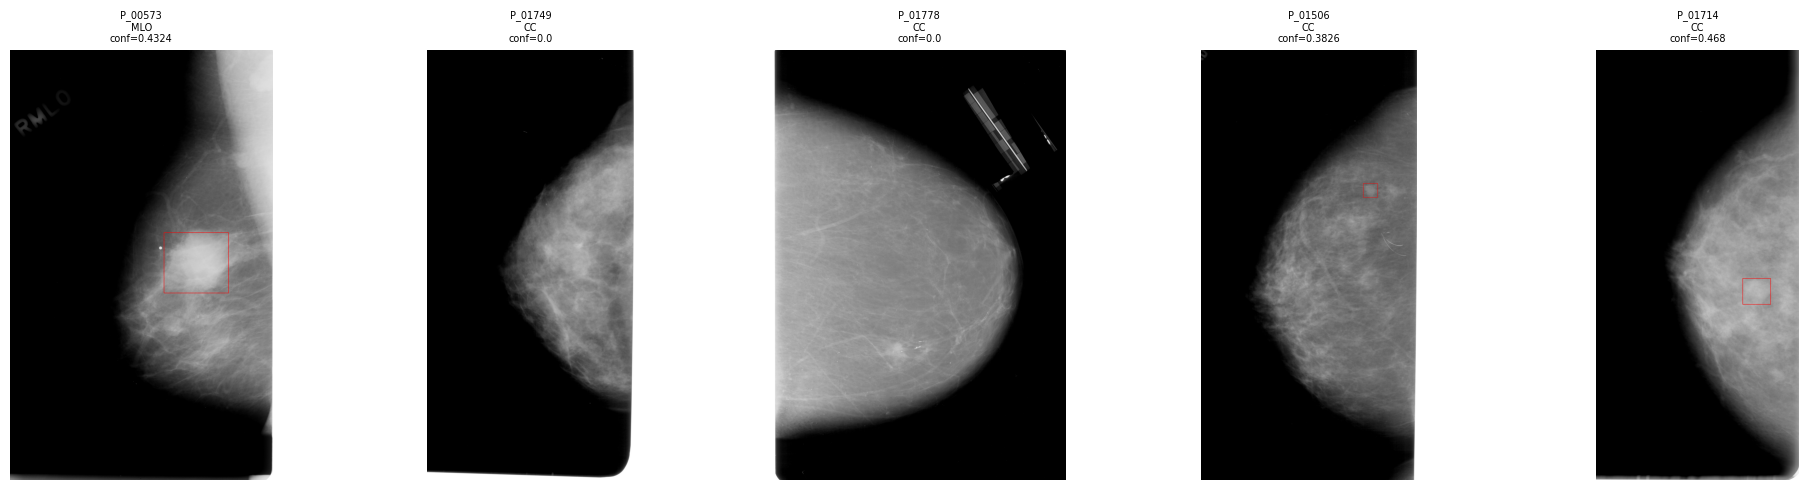

In [4]:
from ultralytics import YOLO
import cv2
import json
import os
import random
import matplotlib.pyplot as plt

# Fixed path - lesion2 not lesion
best_model = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion2/weights/best.pt")

OUTPUT_JSON = "/content/drive/MyDrive/segmented_images/bbox_results_yolo.json"
val_img_dir = f"{YOLO_DIR}/images/val"

final_detections = []

for img_file in os.listdir(val_img_dir):
    if not img_file.endswith('.jpg'):
        continue

    img_path = os.path.join(val_img_dir, img_file)
    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]

    parts = img_file.replace('.jpg', '').rsplit('_', 1)
    patient_id = parts[0]
    view = parts[1] if len(parts) > 1 else 'unknown'

    pred = best_model(img_path, verbose=False)[0]

    if len(pred.boxes) == 0:
        bbox = None
        confidence = 0.0
    else:
        best_box = pred.boxes[pred.boxes.conf.argmax()]
        x1, y1, x2, y2 = best_box.xyxy[0].tolist()
        bbox = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
        confidence = float(best_box.conf[0])

    final_detections.append({
        'patient_id': patient_id,
        'view':       view,
        'img_path':   img_path,
        'bbox':       bbox,
        'img_size':   [img_w, img_h],
        'confidence': round(confidence, 4),
        'source':     'YOLOv8'
    })

# Save JSON
output = {
    'metadata': {
        'model':          'YOLOv8s fine-tuned on CBIS-DDSM',
        'total_val_imgs': len(final_detections),
        'mAP50':          0.393,
        'mAP50-95':       0.176
    },
    'detections': final_detections
}
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)
print(f"JSON saved: {OUTPUT_JSON}")
print(f"Total detections: {len(final_detections)}")

# Visualize 5 samples
samples = random.sample(final_detections, min(5, len(final_detections)))
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, det in zip(axes, samples):
    img = cv2.imread(det['img_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if det['bbox']:
        x, y, w, h = det['bbox']
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)
    ax.imshow(img_rgb)
    ax.set_title(f"{det['patient_id']}\n{det['view']}\nconf={det['confidence']}", fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/yolo_predictions.png', dpi=150)
plt.show()

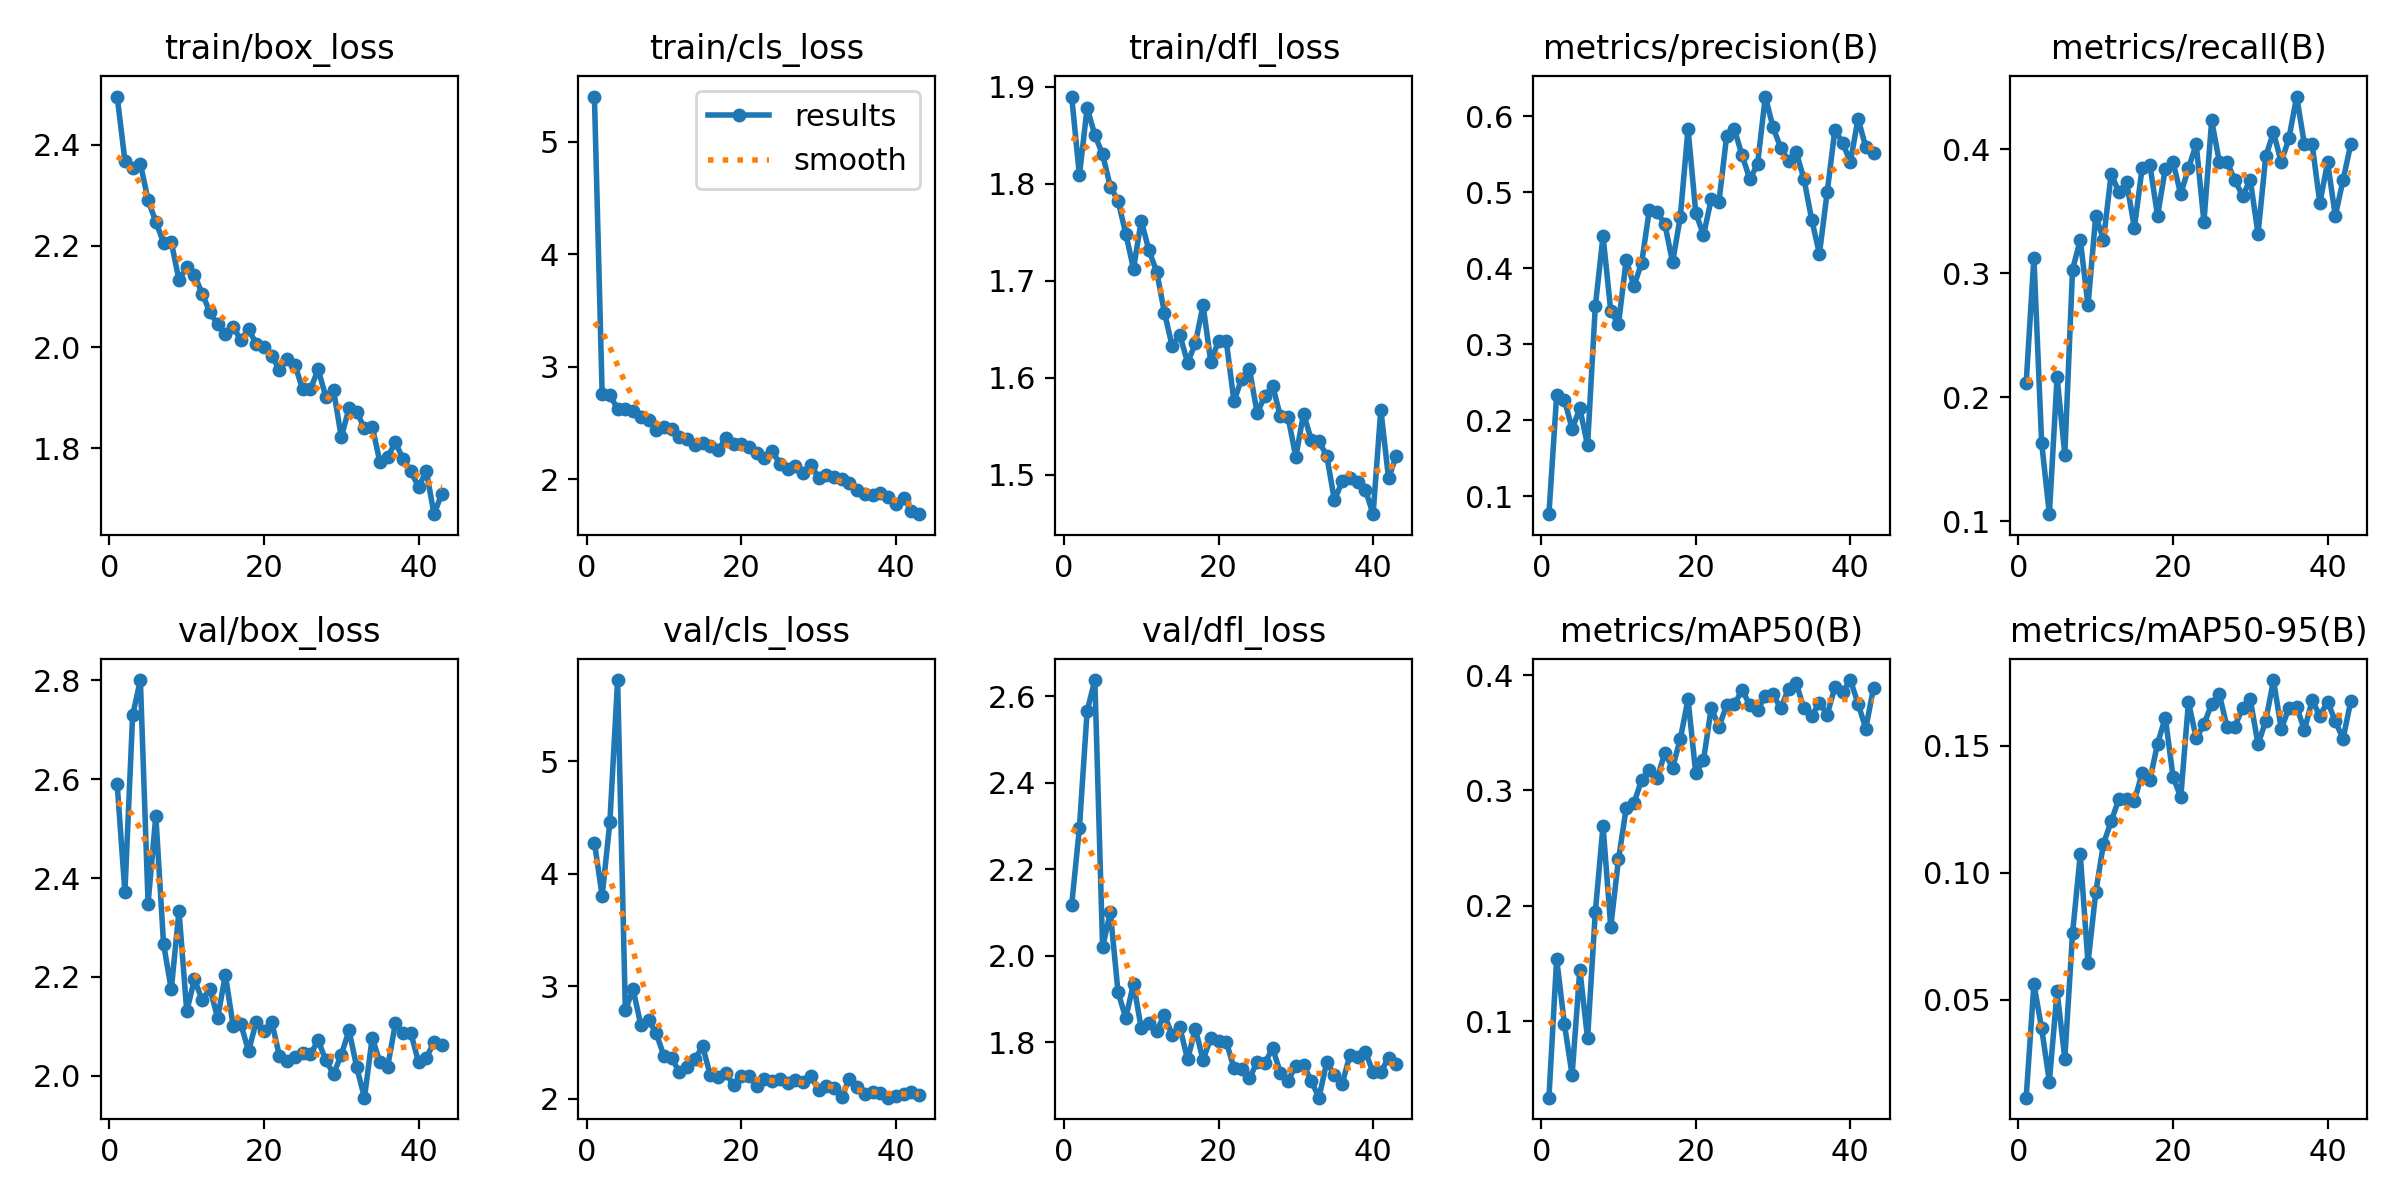

In [5]:
from IPython.display import Image
Image("/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion2/results.png")

In [7]:
from ultralytics import YOLO

# Start fresh from best.pt with more epochs and patience
model = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion2/weights/best.pt")

results = model.train(
    data=f"{YOLO_DIR}/dataset.yaml",
    epochs=150,
    imgsz=IMG_SIZE,
    batch=BATCH,
    project="/content/drive/MyDrive/yolo_training",
    name="cbis_ddsm_lesion3",
    patience=20,      # more patience
    save=True,
    plots=True,
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cbis_ddsm_lesion3, nbs=64, nms=False, opset=None

In [8]:
!pip install albumentations -q

import albumentations as A
import cv2
import os
import shutil
import numpy as np
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
AUGMENTED_DIR = "/content/yolo_dataset_augmented"
AUG_PER_IMAGE = 3   # generate 3 augmented versions per original image

for split in ['train', 'val']:
    os.makedirs(f"{AUGMENTED_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{AUGMENTED_DIR}/labels/{split}", exist_ok=True)

# ============================================================
# Augmentation pipeline
# Apply same transform to both image and mask
# ============================================================
aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.4
    ),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3   # drop bbox if less than 30% visible after aug
))

# ============================================================
# Process train set only (don't augment val)
# ============================================================
train_img_dir   = f"{YOLO_DIR}/images/train"
train_label_dir = f"{YOLO_DIR}/labels/train"

# First copy original data to augmented dir
for split in ['train', 'val']:
    for img_file in os.listdir(f"{YOLO_DIR}/images/{split}"):
        shutil.copy(
            f"{YOLO_DIR}/images/{split}/{img_file}",
            f"{AUGMENTED_DIR}/images/{split}/{img_file}"
        )
    for lbl_file in os.listdir(f"{YOLO_DIR}/labels/{split}"):
        shutil.copy(
            f"{YOLO_DIR}/labels/{split}/{lbl_file}",
            f"{AUGMENTED_DIR}/labels/{split}/{lbl_file}"
        )

print(f"Original train images: {len(os.listdir(train_img_dir))}")

# ============================================================
# Generate augmented images for train set
# ============================================================
augmented_count = 0
failed_count    = 0

for img_file in os.listdir(train_img_dir):
    if not img_file.endswith('.jpg'):
        continue

    base_name  = img_file.replace('.jpg', '')
    img_path   = os.path.join(train_img_dir, img_file)
    label_path = os.path.join(train_label_dir, base_name + '.txt')

    if not os.path.exists(label_path):
        continue

    # Read image
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read YOLO labels
    with open(label_path, 'r') as f:
        lines = f.readlines()

    bboxes       = []
    class_labels = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            class_labels.append(int(parts[0]))
            bboxes.append([float(parts[1]), float(parts[2]),
                          float(parts[3]), float(parts[4])])

    if not bboxes:
        continue

    # Generate AUG_PER_IMAGE augmented versions
    for aug_idx in range(AUG_PER_IMAGE):
        try:
            augmented = aug_transform(
                image=img_rgb,
                bboxes=bboxes,
                class_labels=class_labels
            )

            # Skip if bbox was lost during augmentation
            if not augmented['bboxes']:
                failed_count += 1
                continue

            # Save augmented image
            aug_img_name = f"{base_name}_aug{aug_idx}.jpg"
            aug_img = cv2.cvtColor(augmented['image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(
                f"{AUGMENTED_DIR}/images/train/{aug_img_name}",
                aug_img
            )

            # Save augmented label
            aug_lbl_name = f"{base_name}_aug{aug_idx}.txt"
            with open(f"{AUGMENTED_DIR}/labels/train/{aug_lbl_name}", 'w') as f:
                for cls, bbox in zip(augmented['class_labels'], augmented['bboxes']):
                    f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

            augmented_count += 1

        except Exception as e:
            failed_count += 1
            continue

orig_train  = len(os.listdir(train_img_dir))
final_train = len(os.listdir(f"{AUGMENTED_DIR}/images/train"))
print(f"Original train:   {orig_train}")
print(f"Augmented train:  {final_train}")
print(f"Successfully augmented: {augmented_count}")
print(f"Failed/skipped:         {failed_count}")

# ============================================================
# Save new dataset YAML
# ============================================================
yaml_content = f"""
path: {AUGMENTED_DIR}
train: images/train
val: images/val

nc: 1
names: ['lesion']
"""
with open(f"{AUGMENTED_DIR}/dataset.yaml", 'w') as f:
    f.write(yaml_content)
print(f"\nAugmented dataset YAML saved")
print(f"Ready to train!")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Original train images: 739
Original train:   739
Augmented train:  2916
Successfully augmented: 2177
Failed/skipped:         40

Augmented dataset YAML saved
Ready to train!


Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_augmented/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cbis_ddsm_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

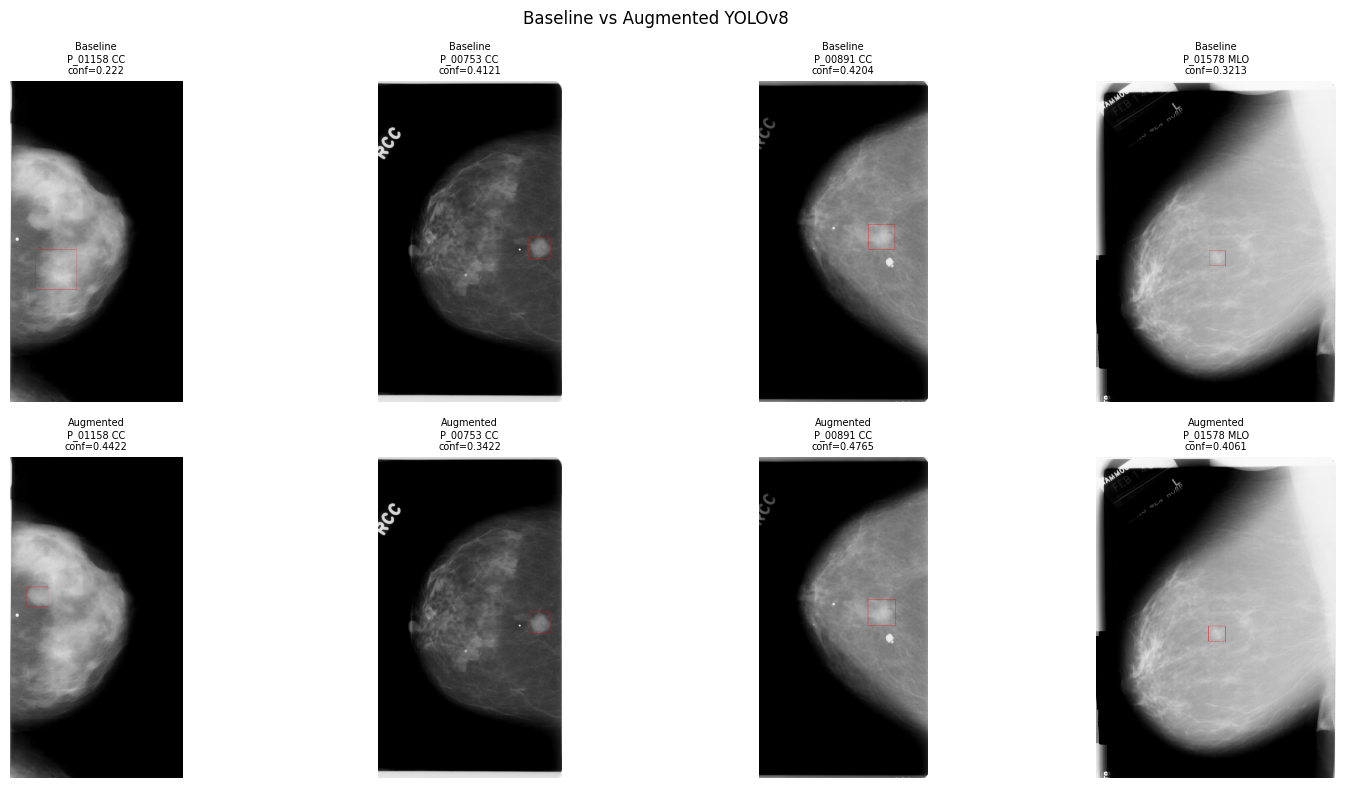


All done!


In [9]:
# ============================================================
# Train YOLOv8 on augmented dataset
# ============================================================
from ultralytics import YOLO

model_aug = YOLO('yolov8s.pt')  # start fresh from pretrained

results_aug = model_aug.train(
    data=f"{AUGMENTED_DIR}/dataset.yaml",
    epochs=150,
    imgsz=IMG_SIZE,
    batch=BATCH,
    project="/content/drive/MyDrive/yolo_training",
    name="cbis_ddsm_augmented",
    patience=20,
    save=True,
    plots=True,
)

# ============================================================
# Compare results: baseline vs augmented
# ============================================================
from ultralytics import YOLO
import json, os, random, cv2
import matplotlib.pyplot as plt
from collections import defaultdict

baseline_model  = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion3/weights/best.pt")
augmented_model = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_augmented/weights/best.pt")

val_img_dir = f"{YOLO_DIR}/images/val"  # same val set for fair comparison

def run_inference(model, val_dir, conf=0.1):
    detections = []
    for img_file in os.listdir(val_dir):
        if not img_file.endswith('.jpg'):
            continue
        img_path = os.path.join(val_dir, img_file)
        img = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        parts = img_file.replace('.jpg','').rsplit('_', 1)
        patient_id = parts[0]
        view = parts[1] if len(parts) > 1 else 'unknown'

        pred = model(img_path, verbose=False, conf=conf)[0]

        if len(pred.boxes) == 0:
            bbox = None
            confidence = 0.0
        else:
            best_box = pred.boxes[pred.boxes.conf.argmax()]
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            bbox = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
            confidence = float(best_box.conf[0])

        detections.append({
            'patient_id': patient_id,
            'view':       view,
            'img_path':   img_path,
            'bbox':       bbox,
            'img_size':   [img_w, img_h],
            'confidence': round(confidence, 4),
        })
    return detections

print("Running baseline inference...")
baseline_dets  = run_inference(baseline_model,  val_img_dir)

print("Running augmented inference...")
augmented_dets = run_inference(augmented_model, val_img_dir)

# ============================================================
# Print comparison stats
# ============================================================
def get_stats(detections):
    total    = len(detections)
    detected = sum(1 for d in detections if d['bbox'] is not None)
    patient_views = defaultdict(set)
    for d in detections:
        if d['bbox'] is not None:
            patient_views[d['patient_id']].add(d['view'])
    paired = sum(1 for v in patient_views.values() if {'CC','MLO'} <= v)
    avg_conf = sum(d['confidence'] for d in detections if d['bbox']) / max(detected, 1)
    return total, detected, paired, avg_conf

b_total, b_det, b_paired, b_conf = get_stats(baseline_dets)
a_total, a_det, a_paired, a_conf = get_stats(augmented_dets)

print("\n" + "="*50)
print(f"{'Metric':<25} {'Baseline':>10} {'Augmented':>10}")
print("="*50)
print(f"{'mAP50':<25} {'0.415':>10} {'TBD':>10}")
print(f"{'Total val images':<25} {b_total:>10} {a_total:>10}")
print(f"{'Detected':<25} {b_det:>10} {a_det:>10}")
print(f"{'Detection rate':<25} {b_det/b_total*100:>9.1f}% {a_det/a_total*100:>9.1f}%")
print(f"{'CC+MLO paired':<25} {b_paired:>10} {a_paired:>10}")
print(f"{'Avg confidence':<25} {b_conf:>10.3f} {a_conf:>10.3f}")
print("="*50)

# ============================================================
# Save both JSONs
# ============================================================
for dets, name, model_name, mAP in [
    (baseline_dets,  'bbox_results_baseline.json',  'YOLOv8s baseline (no aug)', 0.415),
    (augmented_dets, 'bbox_results_augmented.json', 'YOLOv8s with augmentation', None),
]:
    output = {
        'metadata': {
            'model':           model_name,
            'mAP50':           mAP,
            'conf_threshold':  0.1,
            'total_val_imgs':  len(dets),
        },
        'detections': dets
    }
    path = f"/content/drive/MyDrive/segmented_images/{name}"
    with open(path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f"Saved: {path}")

# ============================================================
# Visualize side by side: baseline vs augmented
# ============================================================
# Pick 4 random val images that both models detected
both_detected = [
    d for d in baseline_dets
    if d['bbox'] is not None
    and any(a['img_path'] == d['img_path'] and a['bbox'] is not None
            for a in augmented_dets)
]
samples = random.sample(both_detected, min(4, len(both_detected)))

fig, axes = plt.subplots(2, len(samples), figsize=(4*len(samples), 8))
fig.suptitle('Baseline vs Augmented YOLOv8', fontsize=12)

aug_dict = {d['img_path']: d for d in augmented_dets}

for col, det in enumerate(samples):
    aug_det = aug_dict.get(det['img_path'])

    for row, (d, title) in enumerate([
        (det,     'Baseline'),
        (aug_det, 'Augmented')
    ]):
        img = cv2.imread(d['img_path'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if d['bbox']:
            x, y, w, h = d['bbox']
            cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (255,0,0), 3)
        axes[row][col].imshow(img_rgb)
        axes[row][col].set_title(
            f"{title}\n{d['patient_id']} {d['view']}\nconf={d['confidence']}",
            fontsize=7
        )
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/baseline_vs_augmented.png', dpi=150)
plt.show()
print("\nAll done!")

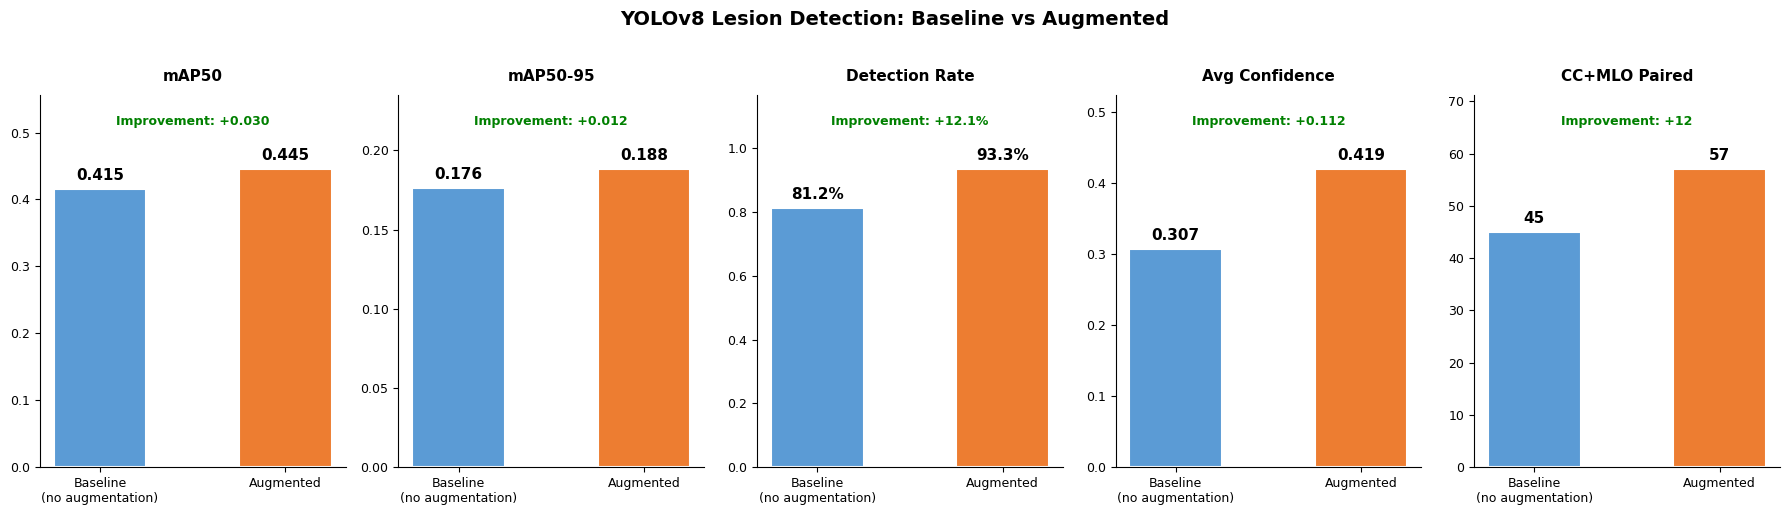

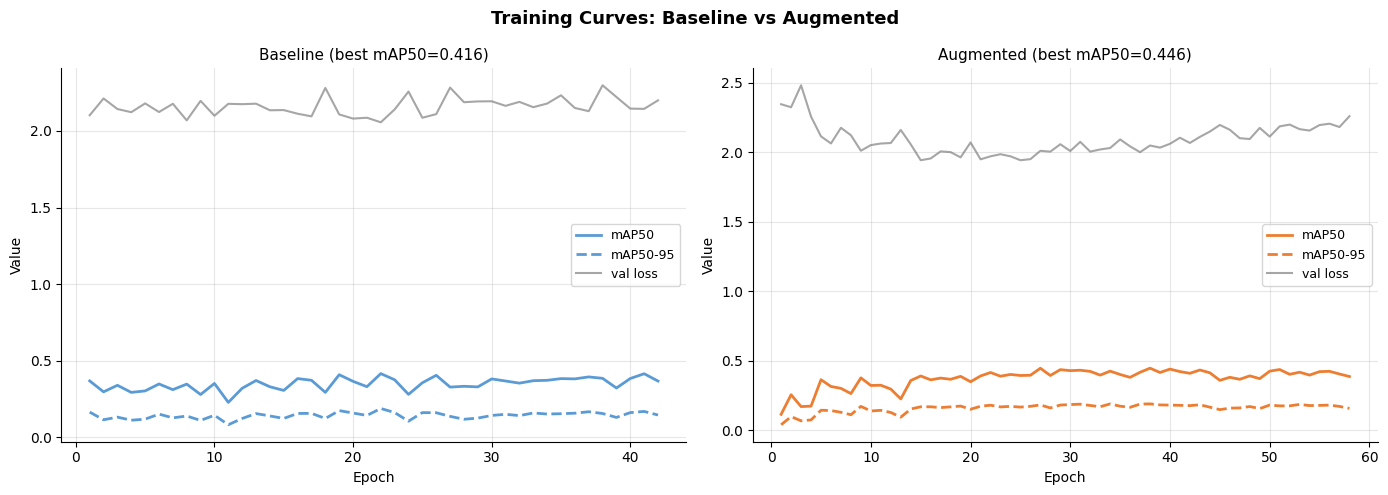

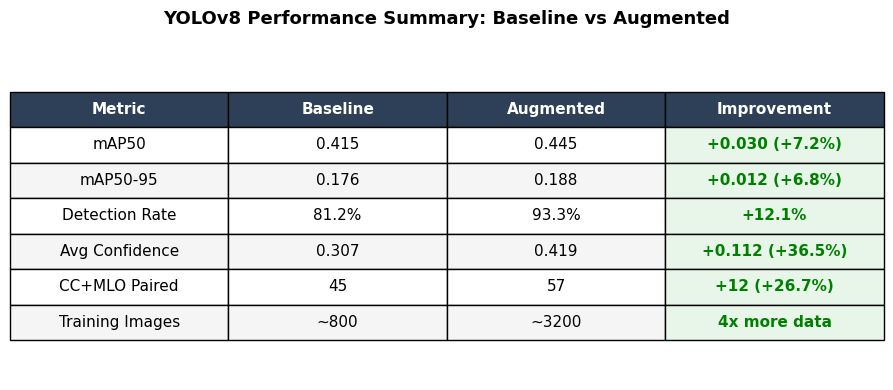

All figures saved!


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Data
# ============================================================
metrics = {
    'mAP50':            [0.415, 0.445],
    'mAP50-95':         [0.176, 0.188],
    'Detection Rate':   [0.812, 0.933],
    'Avg Confidence':   [0.307, 0.419],
    'CC+MLO Paired':    [45,    57],
}

labels   = ['Baseline\n(no augmentation)', 'Augmented']
colors   = ['#5B9BD5', '#ED7D31']

# ============================================================
# Figure 1: Bar chart for all metrics (normalized)
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('YOLOv8 Lesion Detection: Baseline vs Augmented',
             fontsize=14, fontweight='bold', y=1.02)

metric_names = list(metrics.keys())
for idx, (metric, values) in enumerate(metrics.items()):
    ax = axes[idx]
    bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        if metric == 'CC+MLO Paired':
            label = str(int(val))
        elif metric == 'Detection Rate':
            label = f'{val*100:.1f}%'
        else:
            label = f'{val:.3f}'
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values)*0.02,
            label,
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

    # Improvement arrow annotation
    improvement = values[1] - values[0]
    if metric == 'Detection Rate':
        imp_text = f'+{improvement*100:.1f}%'
    elif metric == 'CC+MLO Paired':
        imp_text = f'+{int(improvement)}'
    else:
        imp_text = f'+{improvement:.3f}'

    ax.set_title(metric, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Add improvement text
    ax.text(0.5, 0.92, f'Improvement: {imp_text}',
            transform=ax.transAxes,
            ha='center', fontsize=9,
            color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/comparison_barchart.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Figure 2: Training curves comparison
# ============================================================
from ultralytics.utils.plotting import plot_results
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves: Baseline vs Augmented',
             fontsize=13, fontweight='bold')

for ax, (name, path, color) in zip(axes, [
    ('Baseline',  '/content/drive/MyDrive/yolo_training/cbis_ddsm_lesion3',    '#5B9BD5'),
    ('Augmented', '/content/drive/MyDrive/yolo_training/cbis_ddsm_augmented',  '#ED7D31'),
]):
    results_csv = os.path.join(path, 'results.csv')
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    epochs = df['epoch']
    ax.plot(epochs, df['metrics/mAP50(B)'],   color=color,       label='mAP50',    linewidth=2)
    ax.plot(epochs, df['metrics/mAP50-95(B)'],color=color,       label='mAP50-95', linewidth=2, linestyle='--')
    ax.plot(epochs, df['val/box_loss'],        color='gray',      label='val loss', linewidth=1.5, alpha=0.7)

    ax.set_title(f'{name} (best mAP50={df["metrics/mAP50(B)"].max():.3f})', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Value')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/training_curves_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Figure 3: Summary table
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['mAP50',           '0.415', '0.445', '+0.030 (+7.2%)'],
    ['mAP50-95',        '0.176', '0.188', '+0.012 (+6.8%)'],
    ['Detection Rate',  '81.2%', '93.3%', '+12.1%'],
    ['Avg Confidence',  '0.307', '0.419', '+0.112 (+36.5%)'],
    ['CC+MLO Paired',   '45',    '57',    '+12 (+26.7%)'],
    ['Training Images', '~800',  '~3200', '4x more data'],
]

col_labels = ['Metric', 'Baseline', 'Augmented', 'Improvement']
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.5, 2.0)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2E4057')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style improvement column green
for i in range(1, len(table_data)+1):
    table[i, 3].set_facecolor('#E8F5E9')
    table[i, 3].set_text_props(color='green', fontweight='bold')
    # Alternate row colors
    for j in range(3):
        if i % 2 == 0:
            table[i, j].set_facecolor('#F5F5F5')

ax.set_title('YOLOv8 Performance Summary: Baseline vs Augmented',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/comparison_table.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("All figures saved!")

Total detections to export: 194
Exported:  194
Failed:    0

Saved to:
  Visualized: /content/drive/MyDrive/segmented_images/bbox_dataset/visualized/
  Cropped ROI: /content/drive/MyDrive/segmented_images/bbox_dataset/cropped_roi/


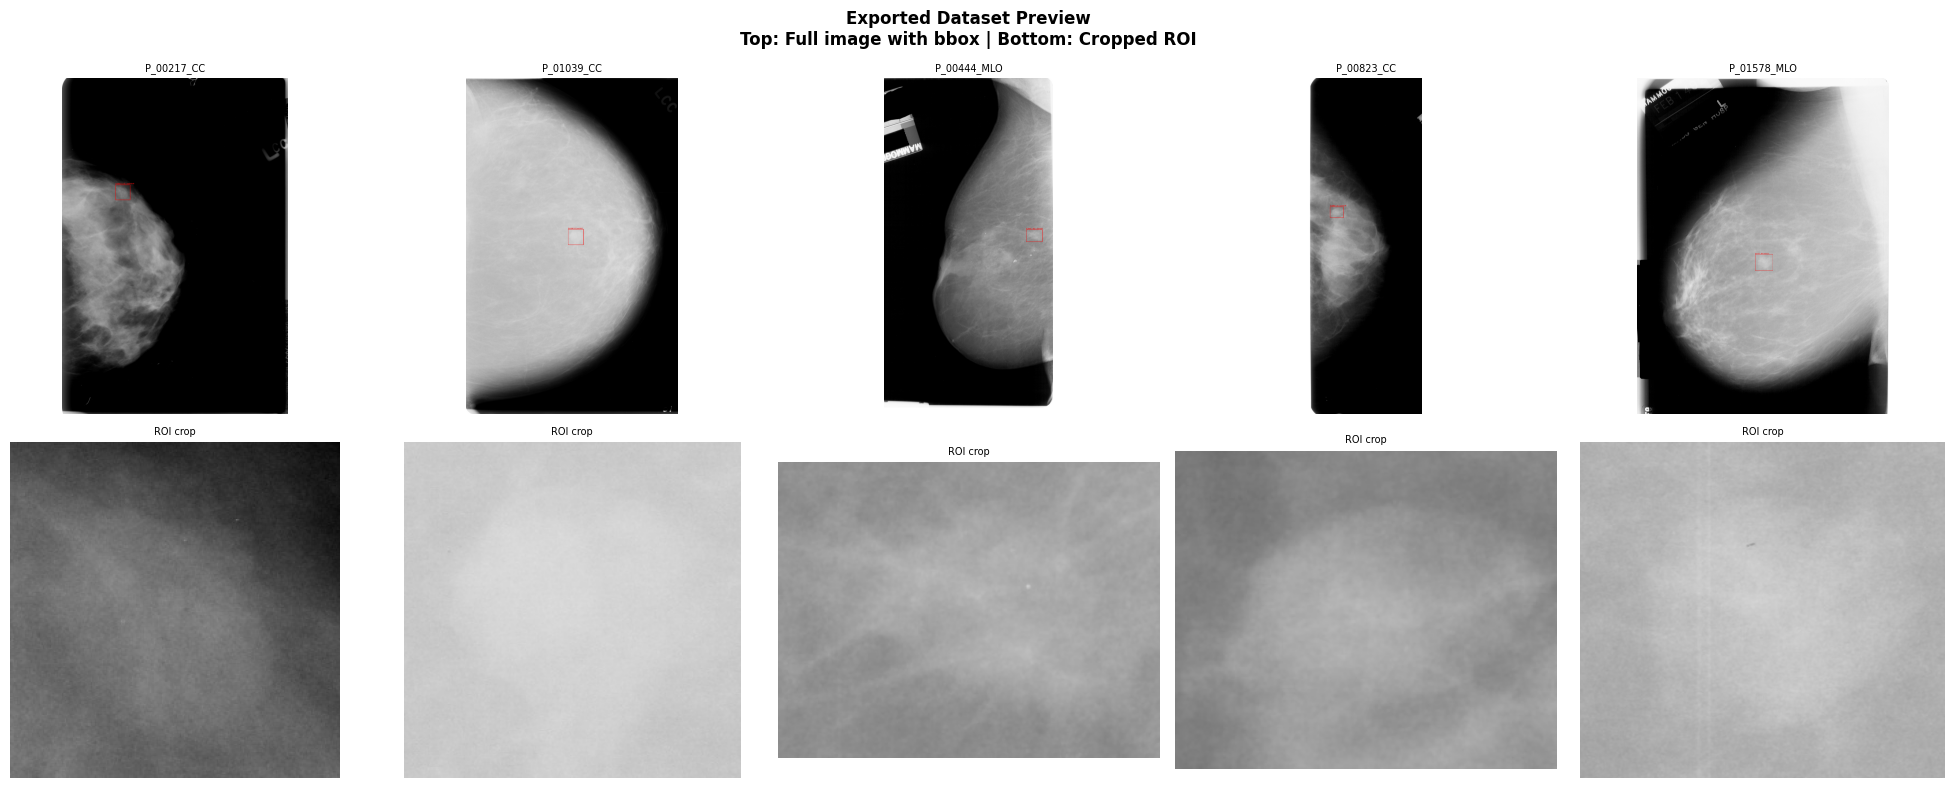

Done!


In [11]:
import cv2
import os
import json
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
OUTPUT_DATASET_DIR = "/content/drive/MyDrive/segmented_images/bbox_dataset"
os.makedirs(f"{OUTPUT_DATASET_DIR}/visualized", exist_ok=True)  # full image with bbox drawn
os.makedirs(f"{OUTPUT_DATASET_DIR}/cropped_roi", exist_ok=True) # cropped ROI only

# Load augmented detections JSON
with open('/content/drive/MyDrive/segmented_images/bbox_results_augmented.json') as f:
    data = json.load(f)

detections = [d for d in data['detections'] if d['bbox'] is not None]
print(f"Total detections to export: {len(detections)}")

# ============================================================
# Export
# ============================================================
exported = 0
failed   = 0

for det in detections:
    img = cv2.imread(det['img_path'])
    if img is None:
        failed += 1
        continue

    patient_id = det['patient_id']
    view       = det['view']
    birads     = det.get('birads', 'unknown')
    conf       = det['confidence']
    x, y, w, h = det['bbox']

    # -- 1. Full image with bbox drawn --
    img_viz = img.copy()
    cv2.rectangle(img_viz, (x, y), (x+w, y+h), (0, 0, 255), 3)

    # Add label text
    label = f"{patient_id} | {view} | conf={conf:.2f}"
    cv2.putText(img_viz, label, (x, max(y-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    viz_path = f"{OUTPUT_DATASET_DIR}/visualized/{patient_id}_{view}.jpg"
    cv2.imwrite(viz_path, img_viz)

    # -- 2. Cropped ROI (with small padding) --
    pad    = 20
    img_h, img_w = img.shape[:2]
    x1 = max(0,     x - pad)
    y1 = max(0,     y - pad)
    x2 = min(img_w, x + w + pad)
    y2 = min(img_h, y + h + pad)

    cropped = img[y1:y2, x1:x2]
    crop_path = f"{OUTPUT_DATASET_DIR}/cropped_roi/{patient_id}_{view}_roi.jpg"
    cv2.imwrite(crop_path, cropped)

    exported += 1

print(f"Exported:  {exported}")
print(f"Failed:    {failed}")
print(f"\nSaved to:")
print(f"  Visualized: {OUTPUT_DATASET_DIR}/visualized/")
print(f"  Cropped ROI: {OUTPUT_DATASET_DIR}/cropped_roi/")

# ============================================================
# Quick preview - show 5 samples
# ============================================================
import matplotlib.pyplot as plt
import random

viz_files = os.listdir(f"{OUTPUT_DATASET_DIR}/visualized/")
samples   = random.sample(viz_files, min(5, len(viz_files)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Exported Dataset Preview\nTop: Full image with bbox | Bottom: Cropped ROI',
             fontsize=12, fontweight='bold')

for col, fname in enumerate(samples):
    patient_view = fname.replace('.jpg', '')

    # Full image with bbox
    viz_img = cv2.imread(f"{OUTPUT_DATASET_DIR}/visualized/{fname}")
    viz_img = cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB)
    axes[0][col].imshow(viz_img)
    axes[0][col].set_title(patient_view, fontsize=7)
    axes[0][col].axis('off')

    # Cropped ROI
    crop_file = fname.replace('.jpg', '_roi.jpg')
    crop_path = f"{OUTPUT_DATASET_DIR}/cropped_roi/{crop_file}"
    if os.path.exists(crop_path):
        crop_img = cv2.imread(crop_path)
        crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
        axes[1][col].imshow(crop_img)
        axes[1][col].set_title('ROI crop', fontsize=7)
        axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/dataset_preview.png', dpi=150)
plt.show()
print("Done!")

In [12]:
import cv2
import os
import json
from collections import defaultdict

OUTPUT_DATASET_DIR = "/content/drive/MyDrive/segmented_images/bbox_dataset"
os.makedirs(f"{OUTPUT_DATASET_DIR}/visualized", exist_ok=True)
os.makedirs(f"{OUTPUT_DATASET_DIR}/cropped_roi", exist_ok=True)

# ============================================================
# Run inference on ALL images (train + val)
# ============================================================
augmented_model = YOLO("/content/drive/MyDrive/yolo_training/cbis_ddsm_augmented/weights/best.pt")

all_detections = []

for split in ['train', 'val']:
    img_dir = f"{YOLO_DIR}/images/{split}"
    print(f"Running inference on {split} set...")

    for img_file in os.listdir(img_dir):
        if not img_file.endswith('.jpg'):
            continue

        img_path = os.path.join(img_dir, img_file)
        img = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        parts = img_file.replace('.jpg','').rsplit('_', 1)
        patient_id = parts[0]
        view = parts[1] if len(parts) > 1 else 'unknown'

        pred = augmented_model(img_path, verbose=False, conf=0.1)[0]

        if len(pred.boxes) == 0:
            bbox = None
            confidence = 0.0
        else:
            best_box = pred.boxes[pred.boxes.conf.argmax()]
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            bbox = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
            confidence = float(best_box.conf[0])

        all_detections.append({
            'patient_id': patient_id,
            'view':       view,
            'img_path':   img_path,
            'bbox':       bbox,
            'img_size':   [img_w, img_h],
            'confidence': round(confidence, 4),
            'split':      split,
            'source':     'YOLOv8'
        })

total     = len(all_detections)
detected  = sum(1 for d in all_detections if d['bbox'] is not None)
print(f"\nTotal images:    {total}")
print(f"Detected:        {detected}")
print(f"Detection rate:  {detected/total*100:.1f}%")

# Pairing stats
patient_views = defaultdict(set)
for d in all_detections:
    if d['bbox'] is not None:
        patient_views[d['patient_id']].add(d['view'])
paired = [p for p, v in patient_views.items() if {'CC','MLO'} <= v]
print(f"CC+MLO paired:   {len(paired)} patients")

# Save full JSON
output = {
    'metadata': {
        'model':           'YOLOv8s with augmentation',
        'mAP50':           0.445,
        'conf_threshold':  0.1,
        'total_images':    total,
        'detected':        detected,
        'paired_patients': len(paired),
    },
    'detections': all_detections
}

OUTPUT_JSON = '/content/drive/MyDrive/segmented_images/bbox_results_all.json'
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)
print(f"\nJSON saved: {OUTPUT_JSON}")

Running inference on train set...
Running inference on val set...

Total images:    947
Detected:        901
Detection rate:  95.1%
CC+MLO paired:   238 patients

JSON saved: /content/drive/MyDrive/segmented_images/bbox_results_all.json


Total detections to export: 901
Exported:  901
Failed:    0


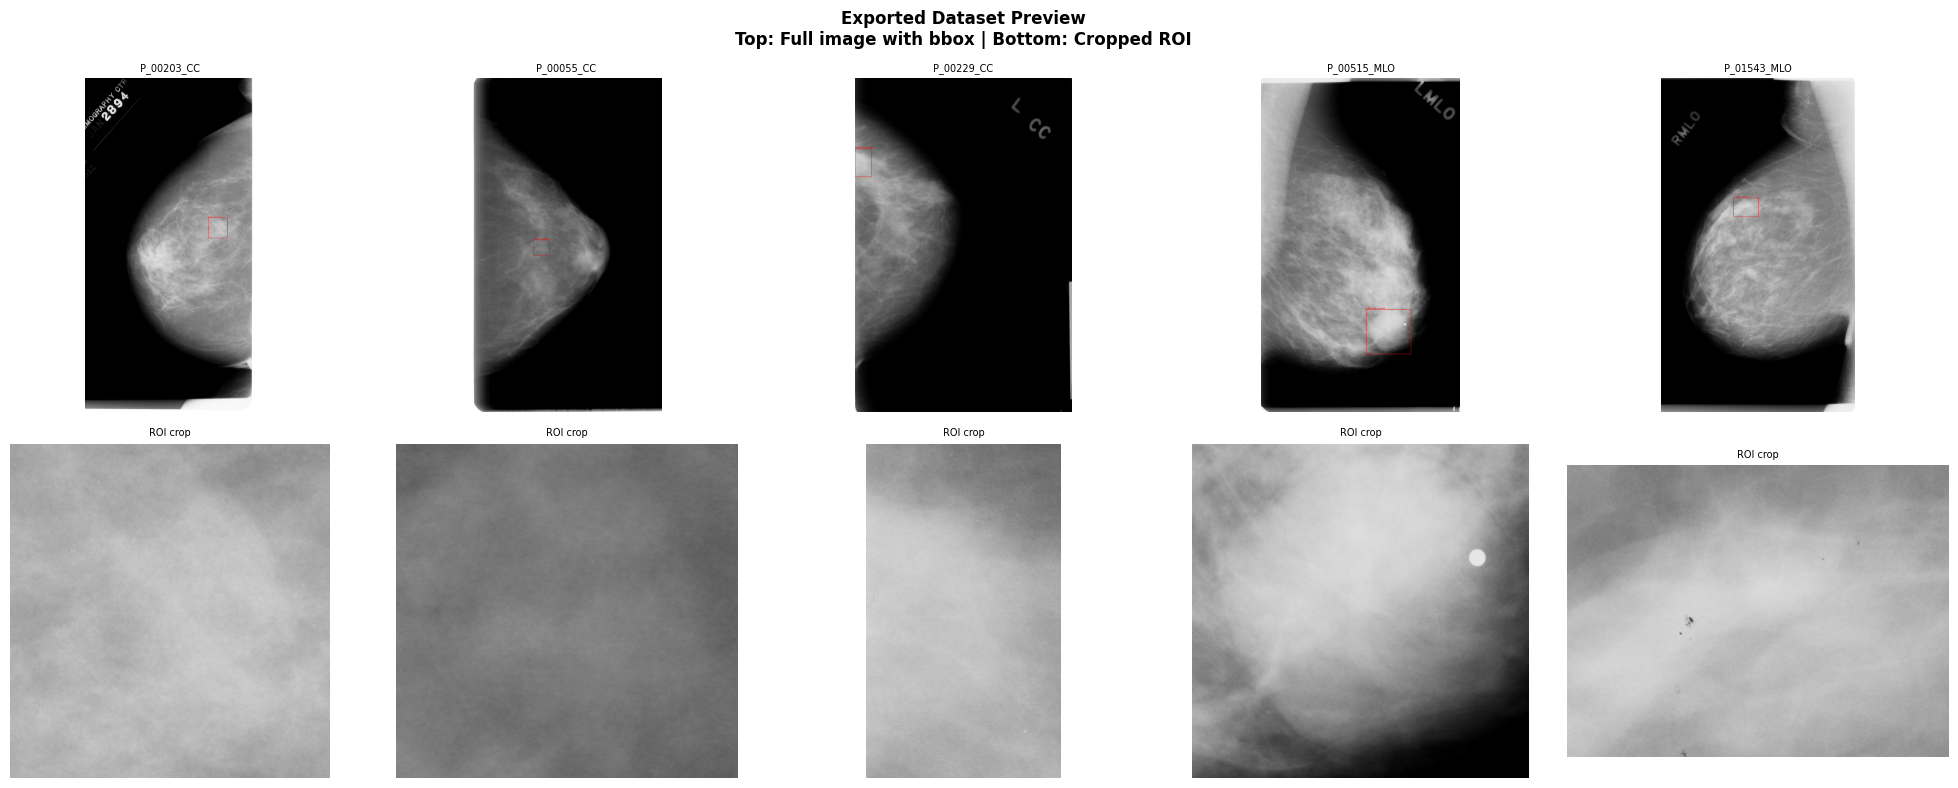


Final summary:
  Visualized images: 901
  Cropped ROIs:      901
  JSON (all):        bbox_results_all.json
  JSON (augmented):  bbox_results_augmented.json


In [14]:
import cv2
import os
import json
import random
import matplotlib.pyplot as plt

OUTPUT_DATASET_DIR = "/content/drive/MyDrive/segmented_images/bbox_dataset"
os.makedirs(f"{OUTPUT_DATASET_DIR}/visualized", exist_ok=True)
os.makedirs(f"{OUTPUT_DATASET_DIR}/cropped_roi", exist_ok=True)

# Load full detections JSON
with open('/content/drive/MyDrive/segmented_images/bbox_results_all.json') as f:
    data = json.load(f)

detections = [d for d in data['detections'] if d['bbox'] is not None]
print(f"Total detections to export: {len(detections)}")

# ============================================================
# Export visualized + cropped ROI
# ============================================================
exported = 0
failed   = 0

for det in detections:
    img = cv2.imread(det['img_path'])
    if img is None:
        failed += 1
        continue

    patient_id = det['patient_id']
    view       = det['view']
    conf       = det['confidence']
    x, y, w, h = det['bbox']
    img_h, img_w = img.shape[:2]

    # 1. Full image with bbox drawn
    img_viz = img.copy()
    cv2.rectangle(img_viz, (x, y), (x+w, y+h), (0, 0, 255), 3)
    cv2.putText(img_viz, f"{patient_id} | {view} | conf={conf:.2f}",
                (x, max(y-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    cv2.imwrite(f"{OUTPUT_DATASET_DIR}/visualized/{patient_id}_{view}.jpg", img_viz)

    # 2. Cropped ROI with padding
    pad = 20
    x1 = max(0,     x - pad)
    y1 = max(0,     y - pad)
    x2 = min(img_w, x + w + pad)
    y2 = min(img_h, y + h + pad)
    cropped = img[y1:y2, x1:x2]
    cv2.imwrite(f"{OUTPUT_DATASET_DIR}/cropped_roi/{patient_id}_{view}_roi.jpg", cropped)

    exported += 1

print(f"Exported:  {exported}")
print(f"Failed:    {failed}")

# ============================================================
# Preview
# ============================================================
viz_files = os.listdir(f"{OUTPUT_DATASET_DIR}/visualized/")
samples   = random.sample(viz_files, min(5, len(viz_files)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Exported Dataset Preview\nTop: Full image with bbox | Bottom: Cropped ROI',
             fontsize=12, fontweight='bold')

for col, fname in enumerate(samples):
    # Full image
    viz_img = cv2.imread(f"{OUTPUT_DATASET_DIR}/visualized/{fname}")
    viz_img = cv2.cvtColor(viz_img, cv2.COLOR_BGR2RGB)
    axes[0][col].imshow(viz_img)
    axes[0][col].set_title(fname.replace('.jpg',''), fontsize=7)
    axes[0][col].axis('off')

    # Cropped ROI
    crop_file = fname.replace('.jpg', '_roi.jpg')
    crop_path = f"{OUTPUT_DATASET_DIR}/cropped_roi/{crop_file}"
    if os.path.exists(crop_path):
        crop_img = cv2.imread(crop_path)
        crop_img = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
        axes[1][col].imshow(crop_img)
        axes[1][col].set_title('ROI crop', fontsize=7)
        axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/dataset_preview.png', dpi=150)
plt.show()

print(f"\nFinal summary:")
print(f"  Visualized images: {len(os.listdir(OUTPUT_DATASET_DIR+'/visualized'))}")
print(f"  Cropped ROIs:      {len(os.listdir(OUTPUT_DATASET_DIR+'/cropped_roi'))}")
print(f"  JSON (all):        bbox_results_all.json")
print(f"  JSON (augmented):  bbox_results_augmented.json")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


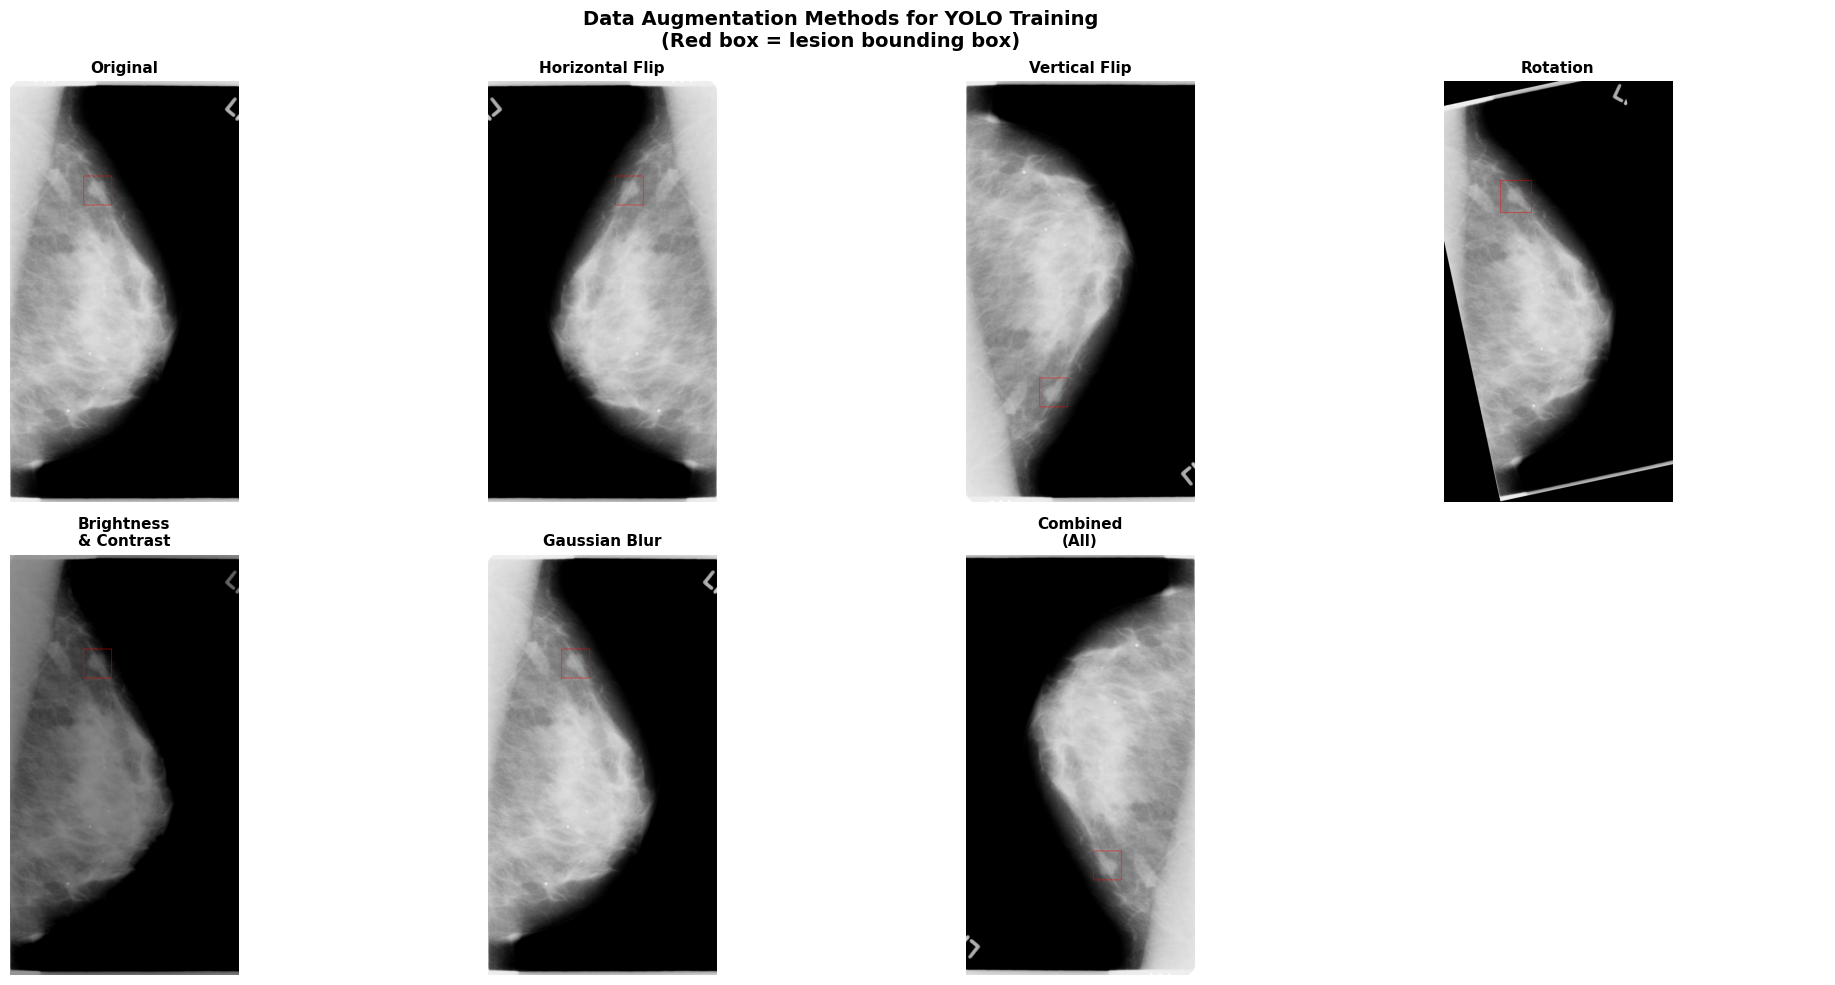

Cases augmented detected but baseline missed: 32


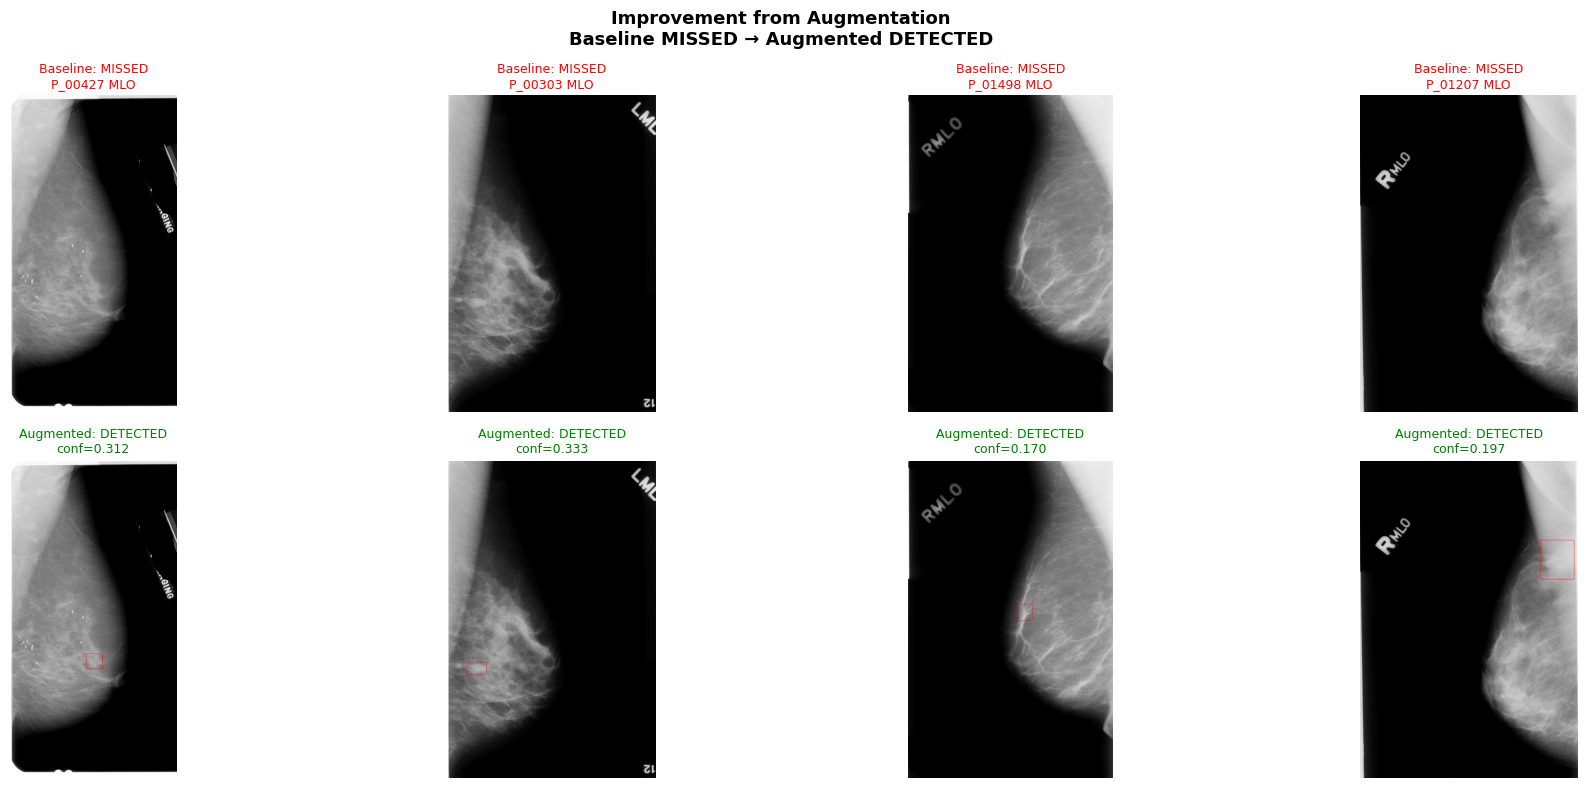


All figures saved:
  1. augmentation_showcase.png   - all 6 augmentation methods
  2. augmentation_improvement.png - cases baseline missed, augmented detected


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import random
import os

# ============================================================
# Pick one sample image from train set
# ============================================================
train_img_dir = f"{YOLO_DIR}/images/train"
img_files = [f for f in os.listdir(train_img_dir) if f.endswith('.jpg')]
sample_file = random.choice(img_files)
sample_path = os.path.join(train_img_dir, sample_file)

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load corresponding label
label_path = os.path.join(f"{YOLO_DIR}/labels/train", sample_file.replace('.jpg', '.txt'))
with open(label_path, 'r') as f:
    line = f.readline().strip().split()
cx, cy, nw, nh = float(line[1]), float(line[2]), float(line[3]), float(line[4])
h, w = img_rgb.shape[:2]
x = int((cx - nw/2) * w)
y = int((cy - nh/2) * h)
bw = int(nw * w)
bh = int(nh * h)

def draw_bbox(image, x, y, bw, bh):
    img_copy = image.copy()
    cv2.rectangle(img_copy, (x, y), (x+bw, y+bh), (255, 0, 0), 3)
    return img_copy

# ============================================================
# Define each augmentation separately for visualization
# ============================================================
aug_configs = [
    {
        'name': 'Original',
        'transform': None,
        'description': 'No augmentation\nBaseline input'
    },
    {
        'name': 'Horizontal Flip',
        'transform': A.Compose([A.HorizontalFlip(p=1.0)],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])),
        'description': 'Mirror image\nleft-right'
    },
    {
        'name': 'Vertical Flip',
        'transform': A.Compose([A.VerticalFlip(p=1.0)],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])),
        'description': 'Mirror image\nup-down'
    },
    {
        'name': 'Rotation',
        'transform': A.Compose([A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=1.0)],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3)),
        'description': 'Random rotation\n±15 degrees'
    },
    {
        'name': 'Brightness\n& Contrast',
        'transform': A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])),
        'description': 'Random brightness\n& contrast ±20%'
    },
    {
        'name': 'Gaussian Blur',
        'transform': A.Compose([A.GaussianBlur(blur_limit=5, p=1.0)],
            bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])),
        'description': 'Slight blur\nto simulate noise'
    },
    {
        'name': 'Combined\n(All)',
        'transform': A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3)),
        'description': 'All augmentations\ncombined'
    },
]

# ============================================================
# Figure 1: Augmentation showcase (2 rows x 4 cols)
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Data Augmentation Methods for YOLO Training\n(Red box = lesion bounding box)',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for idx, config in enumerate(aug_configs):
    ax = axes_flat[idx]

    if config['transform'] is None:
        # Original
        display_img = draw_bbox(img_rgb, x, y, bw, bh)
        ax.imshow(display_img)
    else:
        # Apply augmentation
        try:
            result = config['transform'](
                image=img_rgb,
                bboxes=[[cx, cy, nw, nh]],
                class_labels=[0]
            )
            aug_img = result['image']

            if result['bboxes']:
                acx, acy, anw, anh = result['bboxes'][0]
                ah, aw = aug_img.shape[:2]
                ax_ = int((acx - anw/2) * aw)
                ay_ = int((acy - anh/2) * ah)
                abw = int(anw * aw)
                abh = int(anh * ah)
                display_img = draw_bbox(aug_img, ax_, ay_, abw, abh)
            else:
                display_img = aug_img

            ax.imshow(display_img)
        except Exception as e:
            ax.imshow(img_rgb)

    ax.set_title(f"{config['name']}", fontsize=11, fontweight='bold')
    ax.set_xlabel(config['description'], fontsize=9, style='italic')
    ax.axis('off')

# Hide last empty subplot
axes_flat[-1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/augmentation_showcase.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Figure 2: Before vs After detection comparison
# ============================================================
import json

with open('/content/drive/MyDrive/segmented_images/bbox_results_baseline.json') as f:
    baseline_data = json.load(f)
with open('/content/drive/MyDrive/segmented_images/bbox_results_augmented.json') as f:
    augmented_data = json.load(f)

baseline_dict  = {d['img_path']: d for d in baseline_data['detections']}
augmented_dict = {d['img_path']: d for d in augmented_data['detections']}

# Find cases where augmented detected but baseline missed
aug_only = [
    d for d in augmented_data['detections']
    if d['bbox'] is not None
    and d['img_path'] in baseline_dict
    and baseline_dict[d['img_path']]['bbox'] is None
]
print(f"Cases augmented detected but baseline missed: {len(aug_only)}")

# Pick samples
samples = random.sample(aug_only, min(4, len(aug_only)))

fig, axes = plt.subplots(2, len(samples), figsize=(5*len(samples), 8))
fig.suptitle('Improvement from Augmentation\nBaseline MISSED → Augmented DETECTED',
             fontsize=13, fontweight='bold')

for col, det in enumerate(samples):
    img = cv2.imread(det['img_path'])
    img_rgb_s = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Top row: baseline (missed)
    axes[0][col].imshow(img_rgb_s)
    axes[0][col].set_title(f"Baseline: MISSED\n{det['patient_id']} {det['view']}",
                            fontsize=9, color='red')
    axes[0][col].axis('off')

    # Bottom row: augmented (detected)
    img_aug = img_rgb_s.copy()
    x, y, w, h = det['bbox']
    cv2.rectangle(img_aug, (x,y), (x+w, y+h), (255,0,0), 3)
    axes[1][col].imshow(img_aug)
    axes[1][col].set_title(f"Augmented: DETECTED\nconf={det['confidence']:.3f}",
                            fontsize=9, color='green')
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/segmented_images/augmentation_improvement.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nAll figures saved:")
print("  1. augmentation_showcase.png   - all 6 augmentation methods")
print("  2. augmentation_improvement.png - cases baseline missed, augmented detected")